In [1]:
# =========================================
# 0) Environment & Random Seed
# =========================================
import sys, subprocess
def pip_install(pkg):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# The package name for mRMR is mrmr-selection
pip_install("mrmr-selection")
pip_install("scikit-learn")
pip_install("pandas")
pip_install("numpy")

import numpy as np
import pandas as pd
import random
from collections import Counter

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    accuracy_score, f1_score, roc_auc_score
)
from mrmr import mrmr_regression, mrmr_classif

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Bootstrap settings for 95% CI
N_BOOT = 1000
ALPHA  = 0.05

# =========================================
# 1) Parameters
# =========================================
CSV_PATH = r""   # <-- change this to your path
ID_COL   = "RID"
TIME_COL = "Month"

TARGET_MMSE = "MMSE"   # Regression target
TARGET_DX   = "DX"     # Classification target (numeric 0/1/2; if not, it will be encoded)

TOPK_LIST = [5, 10, 15, 20, 30]   # K values for ablation

# MLP hyperparameters (unchanged)
MLP_REG_PARAMS = dict(hidden_layer_sizes=(128, 64),
                      activation="relu", solver="adam",
                      learning_rate_init=1e-3, max_iter=500,
                      early_stopping=True, n_iter_no_change=20,
                      random_state=SEED)

MLP_CLS_PARAMS = dict(hidden_layer_sizes=(128, 64),
                      activation="relu", solver="adam",
                      learning_rate_init=1e-3, max_iter=500,
                      early_stopping=True, n_iter_no_change=20,
                      random_state=SEED)

# =========================================
# 2) Load Data & Sort
# =========================================
df = pd.read_csv(CSV_PATH)
assert ID_COL in df.columns and TIME_COL in df.columns, "RID or Month column not found"
assert TARGET_MMSE in df.columns, f"Target column {TARGET_MMSE} not found"
assert TARGET_DX   in df.columns, f"Target column {TARGET_DX} not found"

df = df.sort_values([ID_COL, TIME_COL])

# Build samples (t -> nearest future t')
df_t   = df.copy().rename(columns=lambda c: c if c==ID_COL else f"{c}_t")
df_tp1 = df.copy().rename(columns=lambda c: c if c==ID_COL else f"{c}_tp1")

pairs = pd.merge(df_t, df_tp1, on=ID_COL, how="inner")
pairs["dt"] = pairs[f"{TIME_COL}_tp1"] - pairs[f"{TIME_COL}_t"]
pairs = pairs[pairs["dt"] > 0]  # future only
pairs = pairs.sort_values([ID_COL, f"{TIME_COL}_t", "dt"])
pairs = pairs.drop_duplicates(subset=[ID_COL, f"{TIME_COL}_t"], keep="first").reset_index(drop=True)

y_mmse_all = pairs[f"{TARGET_MMSE}_tp1"].copy()
y_dx_all   = pairs[f"{TARGET_DX}_tp1"].copy()

X_all = pairs.filter(regex=r"_t$").copy()
if f"{TIME_COL}_t" in X_all.columns:
    X_all = X_all.drop(columns=[f"{TIME_COL}_t"])
X_all["dt"] = pairs["dt"].values

valid_idx = y_mmse_all.notna() & y_dx_all.notna()
X_all = X_all.loc[valid_idx].reset_index(drop=True)
y_mmse_all = y_mmse_all.loc[valid_idx].reset_index(drop=True)
y_dx_all   = y_dx_all.loc[valid_idx].reset_index(drop=True)
X_all = X_all.select_dtypes(include=[np.number])

# =========================================
# 3) Train/Val/Test split by subject (7:2:1)
# =========================================
rid_series_all = pairs.loc[valid_idx, ID_COL].reset_index(drop=True)
unique_rids = rid_series_all.unique()
rid_train, rid_temp = train_test_split(unique_rids, test_size=0.30, random_state=SEED)
rid_test, rid_val = train_test_split(rid_temp, test_size=(1/3), random_state=SEED)

def mask_by_rids(rids):
    return rid_series_all.isin(set(rids)).values

mask_train = mask_by_rids(rid_train)
mask_val   = mask_by_rids(rid_val)
mask_test  = mask_by_rids(rid_test)

X_train_raw, y_mmse_train_raw, y_dx_train_raw = X_all[mask_train], y_mmse_all[mask_train], y_dx_all[mask_train]
X_val_raw,   y_mmse_val_raw,   y_dx_val_raw   = X_all[mask_val],   y_mmse_all[mask_val],   y_dx_all[mask_val]
X_test_raw,  y_mmse_test_raw,  y_dx_test_raw  = X_all[mask_test],  y_mmse_all[mask_test],  y_dx_all[mask_test]

print("Samples (train/val/test):", len(X_train_raw), len(X_val_raw), len(X_test_raw))

# =========================================
# 4) Encode DX labels
# =========================================
le = LabelEncoder()
y_dx_train_enc = le.fit_transform(pd.to_numeric(y_dx_train_raw, errors="coerce"))
y_dx_val_enc   = le.transform(pd.to_numeric(y_dx_val_raw, errors="coerce"))

# =========================================
# 5) Helper functions
# =========================================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def ensure_dt(features, X):
    """Ensure 'dt' is included in selected features (replace the last one if needed)."""
    if "dt" not in features and "dt" in X.columns and len(features) > 0:
        return features[:-1] + ["dt"]
    return features

def bootstrap_ci(metric_fn, y_true, y_pred, n_boot=N_BOOT, alpha=ALPHA, seed=SEED):
    """
    Non-parametric bootstrap CI for a metric computed on (y_true, y_pred).
    Returns (mean, low, high).
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    stats = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n, endpoint=False)
        stats.append(metric_fn(y_true[idx], y_pred[idx]))
    stats = np.array(stats, dtype=float)
    stats.sort()
    low  = np.percentile(stats, 100*alpha/2)
    high = np.percentile(stats, 100*(1 - alpha/2))
    return float(stats.mean()), float(low), float(high)

def bootstrap_auc_ci(y_true, proba, n_boot=N_BOOT, alpha=ALPHA, seed=SEED):
    """
    Bootstrap CI for multiclass (or binary) ROC AUC using predicted probabilities.
    Uses macro average with OVR for multiclass.
    Returns (mean, low, high).
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    proba  = np.asarray(proba)
    n = len(y_true)
    stats = []
    for _ in range(n_boot):
        # Resample until at least 2 classes are present in the sample
        for _retry in range(50):
            idx = rng.integers(0, n, size=n, endpoint=False)
            if np.unique(y_true[idx]).size >= 2:
                break
        else:
            # If failed to get >=2 classes, skip this replicate
            continue
        try:
            if proba.ndim == 1 or proba.shape[1] == 1:
                # Degenerate; not expected for scikit MLP, but guard anyway
                auc = roc_auc_score(y_true[idx], proba[idx])
            elif proba.shape[1] == 2:
                # Binary: use positive class prob
                auc = roc_auc_score(y_true[idx], proba[idx, 1])
            else:
                # Multiclass: macro OVR
                auc = roc_auc_score(y_true[idx], proba[idx, :], multi_class="ovr", average="macro")
            stats.append(auc)
        except ValueError:
            # e.g., only one class present after resample (should be guarded)
            continue
    stats = np.array(stats, dtype=float)
    stats.sort()
    low  = np.percentile(stats, 100*alpha/2)
    high = np.percentile(stats, 100*(1 - alpha/2))
    return float(np.nanmean(stats)), float(low), float(high)

def fmt(mean, lo, hi, nd=3):
    """Format mean and 95% CI as 'm (lo-hi)'."""
    return f"{mean:.{nd}f} ({lo:.{nd}f}-{hi:.{nd}f})"

# =========================================
# 6) Run ablation over K values and collect results
# =========================================
rows_for_csv = []

for K in TOPK_LIST:
    # ----- mRMR feature selection -----
    train_means = X_train_raw.mean()
    Xtr_filled  = X_train_raw.copy().fillna(train_means)

    sel_mmse = mrmr_regression(X=Xtr_filled, y=y_mmse_train_raw, K=K)
    sel_mmse = ensure_dt(sel_mmse, Xtr_filled)

    sel_dx   = mrmr_classif(X=Xtr_filled, y=y_dx_train_enc, K=K)
    sel_dx   = ensure_dt(sel_dx, Xtr_filled)

    # ----- Build train/val subsets with train means -----
    def fill_like_train(X): return X.copy().fillna(train_means)

    Xtr_mmse = fill_like_train(X_train_raw[sel_mmse])
    Xva_mmse = fill_like_train(X_val_raw[sel_mmse])

    Xtr_dx = fill_like_train(X_train_raw[sel_dx])
    Xva_dx = fill_like_train(X_val_raw[sel_dx])

    # ----- Standardize -----
    scaler_reg = StandardScaler()
    Xtr_mmse_s = scaler_reg.fit_transform(Xtr_mmse)
    Xva_mmse_s = scaler_reg.transform(Xva_mmse)

    scaler_cls = StandardScaler()
    Xtr_dx_s = scaler_cls.fit_transform(Xtr_dx)
    Xva_dx_s = scaler_cls.transform(Xva_dx)

    # ----- Train models -----
    reg = MLPRegressor(**MLP_REG_PARAMS).fit(Xtr_mmse_s, y_mmse_train_raw)
    cls = MLPClassifier(**MLP_CLS_PARAMS).fit(Xtr_dx_s, y_dx_train_enc)

    # ----- Validation predictions -----
    yva_mmse_pred = reg.predict(Xva_mmse_s)
    # For DX we need both predicted labels and probabilities (for AUC)
    yva_dx_pred   = cls.predict(Xva_dx_s)
    yva_dx_proba  = cls.predict_proba(Xva_dx_s)

    # ----- Metrics & 95% CI (bootstrap) -----
    # DX (3 metrics): Accuracy, Macro-F1, AUC (macro, OVR)
    dx_acc_m, dx_acc_lo, dx_acc_hi = bootstrap_ci(accuracy_score, y_dx_val_enc, yva_dx_pred)
    dx_f1_m,  dx_f1_lo,  dx_f1_hi  = bootstrap_ci(lambda y, yhat: f1_score(y, yhat, average="macro", zero_division=0),
                                                  y_dx_val_enc, yva_dx_pred)
    dx_auc_m, dx_auc_lo, dx_auc_hi = bootstrap_auc_ci(y_dx_val_enc, yva_dx_proba)

    # MMSE (2 metrics): RMSE, MAE
    mmse_rmse_m, mmse_rmse_lo, mmse_rmse_hi = bootstrap_ci(
        lambda y, yhat: rmse(y, yhat), y_mmse_val_raw.values, yva_mmse_pred
    )
    mmse_mae_m,  mmse_mae_lo,  mmse_mae_hi  = bootstrap_ci(
        mean_absolute_error, y_mmse_val_raw.values, yva_mmse_pred
    )

    row = {
        "K": K,
        "DX_ACC": dx_acc_m, "DX_ACC_95CI_low": dx_acc_lo, "DX_ACC_95CI_high": dx_acc_hi,
        "DX_F1":  dx_f1_m,  "DX_F1_95CI_low":  dx_f1_lo,  "DX_F1_95CI_high":  dx_f1_hi,
        "DX_AUC": dx_auc_m, "DX_AUC_95CI_low": dx_auc_lo, "DX_AUC_95CI_high": dx_auc_hi,
        "MMSE_RMSE": mmse_rmse_m, "MMSE_RMSE_95CI_low": mmse_rmse_lo, "MMSE_RMSE_95CI_high": mmse_rmse_hi,
        "MMSE_MAE":  mmse_mae_m,  "MMSE_MAE_95CI_low":  mmse_mae_lo,  "MMSE_MAE_95CI_high":  mmse_mae_hi,
        # Pretty strings for paper
        "DX_ACC_pretty":  fmt(dx_acc_m,  dx_acc_lo,  dx_acc_hi),
        "DX_F1_pretty":   fmt(dx_f1_m,   dx_f1_lo,   dx_f1_hi),
        "DX_AUC_pretty":  fmt(dx_auc_m,  dx_auc_lo,  dx_auc_hi),
        "MMSE_RMSE_pretty": fmt(mmse_rmse_m, mmse_rmse_lo, mmse_rmse_hi),
        "MMSE_MAE_pretty":  fmt(mmse_mae_m,  mmse_mae_lo,  mmse_mae_hi),
    }
    rows_for_csv.append(row)

    # ----- Console one-line summary -----
    print(
        f"[K={K}] VAL  "
        f"DX: ACC={row['DX_ACC_pretty']}, "
        f"F1={row['DX_F1_pretty']}, "
        f"AUC={row['DX_AUC_pretty']} | "
        f"MMSE: RMSE={row['MMSE_RMSE_pretty']}, "
        f"MAE={row['MMSE_MAE_pretty']}"
    )

# =========================================
# 7) Save CSVs (no Excel dependency)
# =========================================
df_all = pd.DataFrame(rows_for_csv).sort_values("K")

# Full numeric results (means + CI bounds)
full_csv = "ablation_MLP_full_with_AUC_CI.csv"
df_all.to_csv(full_csv, index=False, encoding="utf-8-sig")
print(f"Saved: {full_csv}")

# Pretty view for paper
pretty_cols = [
    "K",
    "DX_ACC_pretty", "DX_F1_pretty", "DX_AUC_pretty",
    "MMSE_RMSE_pretty", "MMSE_MAE_pretty"
]
df_pretty = df_all[pretty_cols].rename(columns={
    "DX_ACC_pretty": "DX_ACC (95% CI)",
    "DX_F1_pretty":  "DX_MacroF1 (95% CI)",
    "DX_AUC_pretty": "DX_AUC (95% CI)",
    "MMSE_RMSE_pretty": "MMSE_RMSE (95% CI)",
    "MMSE_MAE_pretty":  "MMSE_MAE (95% CI)",
})
pretty_csv = "ablation_MLP_pretty_with_AUC_CI.csv"
df_pretty.to_csv(pretty_csv, index=False, encoding="utf-8-sig")
print(f"Saved: {pretty_csv}")


Samples (train/val/test): 1908 283 556


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 34.16it/s]


[K=5] VAL  DX: ACC=0.929 (0.894-0.958), F1=0.928 (0.895-0.956), AUC=0.979 (0.964-0.990) | MMSE: RMSE=2.208 (1.976-2.437), MAE=1.656 (1.492-1.827)


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 31.56it/s]


[K=10] VAL  DX: ACC=0.940 (0.908-0.965), F1=0.939 (0.910-0.965), AUC=0.984 (0.973-0.993) | MMSE: RMSE=2.164 (1.929-2.390), MAE=1.627 (1.464-1.799)


...

[K=15] VAL  DX: ACC=0.940 (0.908-0.965), F1=0.939 (0.909-0.965), AUC=0.984 (0.973-0.992) | MMSE: RMSE=2.160 (1.935-2.394), MAE=1.612 (1.455-1.779)


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 29.69it/s]


[K=20] VAL  DX: ACC=0.932 (0.901-0.961), F1=0.932 (0.900-0.960), AUC=0.985 (0.973-0.993) | MMSE: RMSE=2.266 (1.970-2.567), MAE=1.653 (1.474-1.827)


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:01<00:00, 29.17it/s]


[K=30] VAL  DX: ACC=0.925 (0.890-0.958), F1=0.925 (0.893-0.957), AUC=0.983 (0.972-0.992) | MMSE: RMSE=2.550 (2.221-2.929), MAE=1.876 (1.676-2.091)
Saved: ablation_MLP_full_with_AUC_CI.csv
Saved: ablation_MLP_pretty_with_AUC_CI.csv


In [2]:
# =========================================
# 0) Environment & Random Seed
# =========================================
import sys, subprocess
def pip_install(pkg):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# The package name for mRMR is mrmr-selection
pip_install("mrmr-selection")
pip_install("scikit-learn")
pip_install("pandas")
pip_install("numpy")

import numpy as np
import pandas as pd
import random
from collections import Counter

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             accuracy_score, f1_score, confusion_matrix,
                             classification_report)

from mrmr import mrmr_regression, mrmr_classif

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# =========================================
# 1) Parameters (modify as needed)
# =========================================
CSV_PATH = r"C:\Users\CaiTianXiang\Desktop\Merged_Cleaned.csv"   # Change to your path
ID_COL   = "RID"
TIME_COL = "Month"

TARGET_MMSE = "MMSE"   # Regression target
TARGET_DX   = "DX"     # Classification target (should be numeric 0/1/2; if not, it will be encoded automatically)

TOPK_MMSE = 10         # mRMR: select top 10 (regression)
TOPK_DX   = 10         # mRMR: select top 10 (classification)

# MLP hyperparameters
MLP_REG_PARAMS = dict(hidden_layer_sizes=(128, 64),
                      activation="relu", solver="adam",
                      learning_rate_init=1e-3, max_iter=500,
                      early_stopping=True, n_iter_no_change=20,
                      random_state=SEED)

MLP_CLS_PARAMS = dict(hidden_layer_sizes=(128, 64),
                      activation="relu", solver="adam",
                      learning_rate_init=1e-3, max_iter=500,
                      early_stopping=True, n_iter_no_change=20,
                      random_state=SEED)

# =========================================
# 2) Load Data & Sort
# =========================================
df = pd.read_csv(CSV_PATH)
assert ID_COL in df.columns and TIME_COL in df.columns, "RID or Month column not found"
assert TARGET_MMSE in df.columns, f"Target column {TARGET_MMSE} not found"
assert TARGET_DX   in df.columns, f"Target column {TARGET_DX} not found"

df = df.sort_values([ID_COL, TIME_COL])

# =========================================
# 3) Build samples for (t → nearest future t')
# =========================================
df_t   = df.copy().rename(columns=lambda c: c if c==ID_COL else f"{c}_t")
df_tp1 = df.copy().rename(columns=lambda c: c if c==ID_COL else f"{c}_tp1")

pairs = pd.merge(df_t, df_tp1, on=ID_COL, how="inner")
pairs["dt"] = pairs[f"{TIME_COL}_tp1"] - pairs[f"{TIME_COL}_t"]
pairs = pairs[pairs["dt"] > 0]  # keep only future

pairs = pairs.sort_values([ID_COL, f"{TIME_COL}_t", "dt"])
pairs = pairs.drop_duplicates(subset=[ID_COL, f"{TIME_COL}_t"], keep="first").reset_index(drop=True)

y_mmse_all = pairs[f"{TARGET_MMSE}_tp1"].copy()
y_dx_all   = pairs[f"{TARGET_DX}_tp1"].copy()

X_all = pairs.filter(regex=r"_t$").copy()
if f"{TIME_COL}_t" in X_all.columns:
    X_all = X_all.drop(columns=[f"{TIME_COL}_t"])

X_all["dt"] = pairs["dt"].values

valid_idx = y_mmse_all.notna() & y_dx_all.notna()
X_all = X_all.loc[valid_idx].reset_index(drop=True)
y_mmse_all = y_mmse_all.loc[valid_idx].reset_index(drop=True)
y_dx_all = y_dx_all.loc[valid_idx].reset_index(drop=True)

X_all = X_all.select_dtypes(include=[np.number])

# =========================================
# 4) Split by subject RID into 7:2:1
# =========================================
rid_series_all = pairs.loc[valid_idx, ID_COL].reset_index(drop=True)

unique_rids = rid_series_all.unique()
rid_train, rid_temp = train_test_split(unique_rids, test_size=0.30, random_state=SEED)
rid_test, rid_val = train_test_split(rid_temp, test_size=(1/3), random_state=SEED)

def mask_by_rids(rids):
    return rid_series_all.isin(set(rids)).values

mask_train = mask_by_rids(rid_train)
mask_test  = mask_by_rids(rid_test)
mask_val   = mask_by_rids(rid_val)

X_train_raw, y_mmse_train_raw, y_dx_train_raw = X_all[mask_train], y_mmse_all[mask_train], y_dx_all[mask_train]
X_test_raw,  y_mmse_test_raw,  y_dx_test_raw  = X_all[mask_test],  y_mmse_all[mask_test],  y_dx_all[mask_test]
X_val_raw,   y_mmse_val_raw,   y_dx_val_raw   = X_all[mask_val],   y_mmse_all[mask_val],   y_dx_all[mask_val]

print("Sample count (train/test/val):", len(X_train_raw), len(X_test_raw), len(X_val_raw))
print("RID count (train/test/val):", len(set(rid_train)), len(set(rid_test)), len(set(rid_val)))

# =========================================
# 5) Label encoding for DX
# =========================================
le = LabelEncoder()
y_dx_train_enc = le.fit_transform(pd.to_numeric(y_dx_train_raw, errors="coerce"))
y_dx_test_enc  = le.transform(pd.to_numeric(y_dx_test_raw,  errors="coerce"))
y_dx_val_enc   = le.transform(pd.to_numeric(y_dx_val_raw,   errors="coerce"))

print("DX label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# =========================================
# 6) mRMR feature selection
# =========================================
Xtr_reg_filled = X_train_raw.copy().fillna(X_train_raw.mean())
sel_mmse = mrmr_regression(X=Xtr_reg_filled, y=y_mmse_train_raw, K=TOPK_MMSE)
if "dt" not in sel_mmse and "dt" in Xtr_reg_filled.columns:
    sel_mmse = sel_mmse[:-1] + ["dt"]
print("Top 10 regression features:", sel_mmse)

Xtr_cls_filled = X_train_raw.copy().fillna(X_train_raw.mean())
sel_dx = mrmr_classif(X=Xtr_cls_filled, y=y_dx_train_enc, K=TOPK_DX)
if "dt" not in sel_dx and "dt" in Xtr_cls_filled.columns:
    sel_dx = sel_dx[:-1] + ["dt"]
print("Top 10 classification features:", sel_dx)

reg_fill_values = Xtr_reg_filled.mean()
cls_fill_values = Xtr_cls_filled.mean()

def fill_like_train(X, fill_vals):
    return X.copy().fillna(fill_vals)

X_train_mmse = fill_like_train(X_train_raw[sel_mmse], reg_fill_values[sel_mmse])
X_val_mmse   = fill_like_train(X_val_raw[sel_mmse],   reg_fill_values[sel_mmse])
X_test_mmse  = fill_like_train(X_test_raw[sel_mmse],  reg_fill_values[sel_mmse])

X_train_dx = fill_like_train(X_train_raw[sel_dx], cls_fill_values[sel_dx])
X_val_dx   = fill_like_train(X_val_raw[sel_dx],   cls_fill_values[sel_dx])
X_test_dx  = fill_like_train(X_test_raw[sel_dx],  cls_fill_values[sel_dx])

# =========================================
# 7) Standardization
# =========================================
scaler_reg = StandardScaler()
X_train_mmse_s = scaler_reg.fit_transform(X_train_mmse)
X_val_mmse_s   = scaler_reg.transform(X_val_mmse)
X_test_mmse_s  = scaler_reg.transform(X_test_mmse)

scaler_cls = StandardScaler()
X_train_dx_s = scaler_cls.fit_transform(X_train_dx)
X_val_dx_s   = scaler_cls.transform(X_val_dx)
X_test_dx_s  = scaler_cls.transform(X_test_dx)

# =========================================
# 8) Train MLP
# =========================================
reg = MLPRegressor(**MLP_REG_PARAMS)
reg.fit(X_train_mmse_s, y_mmse_train_raw)

cls = MLPClassifier(**MLP_CLS_PARAMS)
class_counts = Counter(y_dx_train_enc)
total = sum(class_counts.values())
class_weight = {c: total/(len(class_counts)*cnt) for c,cnt in class_counts.items()}
sample_weight_train = np.array([class_weight[c] for c in y_dx_train_enc], dtype=float)

try:
    cls.fit(X_train_dx_s, y_dx_train_enc, sample_weight=sample_weight_train)
except TypeError:
    cls.fit(X_train_dx_s, y_dx_train_enc)

# =========================================
# 9) Validation evaluation
# =========================================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

y_val_mmse_pred = reg.predict(X_val_mmse_s)
val_rmse = rmse(y_mmse_val_raw, y_val_mmse_pred)
val_mae  = mean_absolute_error(y_mmse_val_raw, y_val_mmse_pred)

y_val_dx_pred  = cls.predict(X_val_dx_s)
val_acc  = accuracy_score(y_dx_val_enc, y_val_dx_pred)
val_f1   = f1_score(y_dx_val_enc, y_val_dx_pred, average="macro")

print("\n[Validation]")
print(f"MMSE:  RMSE={val_rmse:.3f}  MAE={val_mae:.3f}")
print(f"DX:    ACC ={val_acc:.3f}  Macro-F1={val_f1:.3f}")
print("DX validation classification report:\n", classification_report(y_dx_val_enc, y_val_dx_pred))

# =========================================
# 10) Test evaluation
# =========================================
y_test_mmse_pred = reg.predict(X_test_mmse_s)
test_rmse = rmse(y_mmse_test_raw, y_test_mmse_pred)
test_mae  = mean_absolute_error(y_mmse_test_raw, y_test_mmse_pred)

y_test_dx_pred  = cls.predict(X_test_dx_s)
test_acc  = accuracy_score(y_dx_test_enc, y_test_dx_pred)
test_f1   = f1_score(y_dx_test_enc, y_test_dx_pred, average="macro")
cm        = confusion_matrix(y_dx_test_enc, y_test_dx_pred)

print("\n[TEST - Final]")
print(f"MMSE:  RMSE={test_rmse:.3f}  MAE={test_mae:.3f}")
print(f"DX:    ACC ={test_acc:.3f}  Macro-F1={test_f1:.3f}")
print("DX test confusion matrix:\n", cm)
print("DX test classification report:\n", classification_report(y_dx_test_enc, y_test_dx_pred))

# =========================================
# 11) Save key metadata
# =========================================
import json
out = {
    "seed": SEED,
    "rid_counts": {
        "train": len(set(rid_train)),
        "test":  len(set(rid_test)),
        "val":   len(set(rid_val)),
    },
    "n_samples": {
        "train": len(X_train_raw),
        "test":  len(X_test_raw),
        "val":   len(X_val_raw),
    },
    "mrmr_top10_mmse": sel_mmse,
    "mrmr_top10_dx":   sel_dx,
    "mmse_scaler_mean": scaler_reg.mean_.tolist(),
    "mmse_scaler_scale": scaler_reg.scale_.tolist(),
    "dx_scaler_mean": scaler_cls.mean_.tolist(),
    "dx_scaler_scale": scaler_cls.scale_.tolist(),
    "mlp_reg_params": MLP_REG_PARAMS,
    "mlp_cls_params": MLP_CLS_PARAMS,
}
with open("mlp_mrmr_metadata.json", "w", encoding="utf-8") as f:
    json.dump(out, f, ensure_ascii=False, indent=2)

print("\nMetadata saved to mlp_mrmr_metadata.json")


Sample count (train/test/val): 1908 556 283
RID count (train/test/val): 531 152 76
DX label mapping: {np.float64(0.0): np.int64(0), np.float64(1.0): np.int64(1), np.float64(2.0): np.int64(2)}


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 28.49it/s]


Top 10 regression features: ['mPACCdigit_t', 'ST49TS_t', 'MMSE_t', 'mPACCtrailsB_t', 'ADAS11_t', 'ADAS13_t', 'CDRSB_t', 'mPACCtrailsB_bl_t', 'mPACCdigit_bl_t', 'dt']


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 31.53it/s]


Top 10 classification features: ['DX_t', 'LDELTOTAL_BL_t', 'mPACCdigit_bl_t', 'CDRSB_t', 'mPACCtrailsB_bl_t', 'mPACCdigit_t', 'mPACCtrailsB_t', 'FAQ_t', 'ADASQ4_t', 'dt']

[Validation]
MMSE:  RMSE=2.157  MAE=1.619
DX:    ACC =0.936  Macro-F1=0.936
DX validation classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        92
           1       0.88      0.95      0.92       104
           2       0.94      0.86      0.90        87

    accuracy                           0.94       283
   macro avg       0.94      0.93      0.94       283
weighted avg       0.94      0.94      0.94       283


[TEST - Final]
MMSE:  RMSE=2.278  MAE=1.604
DX:    ACC =0.901  Macro-F1=0.904
DX test confusion matrix:
 [[155   6   0]
 [  5 208  18]
 [  0  26 138]]
DX test classification report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97       161
           1       0.87      0.90      0

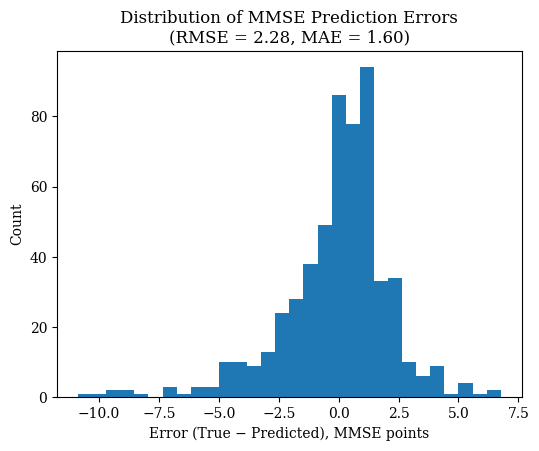

[Saved] figures\mlp_mmse_error_hist.pdf


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------- Minimal, journal-friendly defaults ----------
# Embed TrueType fonts in PDF (Type 42), preferred by many journals
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
# Keep a simple, readable serif font and modest sizes
rcParams["font.family"] = "serif"
rcParams["font.size"] = 10

# Directory for figures
SAVE_DIR = "figures"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------- Compute errors & metrics ----------
# Expect y_mmse_test_raw and y_test_mmse_pred already defined in your workspace
y_true = np.asarray(y_mmse_test_raw, dtype=float)
y_pred = np.asarray(y_test_mmse_pred, dtype=float)

# Drop NaN/Inf if any (defensive)
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

errors = y_true - y_pred
rmse  = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae   = float(mean_absolute_error(y_true, y_pred))

# ---------- Figure: Error distribution histogram ----------
# Single-figure, default style, no custom colors
fig = plt.figure(figsize=(6, 4.5))
ax = fig.add_subplot(111)

ax.hist(errors, bins=30)  # default appearance (not flashy)
ax.set_title(f"Distribution of MMSE Prediction Errors\n(RMSE = {rmse:.2f}, MAE = {mae:.2f})")
ax.set_xlabel("Error (True − Predicted), MMSE points")
ax.set_ylabel("Count")

# Save as vector PDF with clear labels; do not display
pdf_path = os.path.join(SAVE_DIR, "mlp_mmse_error_hist.pdf")
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"[Saved] {pdf_path}")


[Saved] figures\mlp_tsne_dx_test.pdf


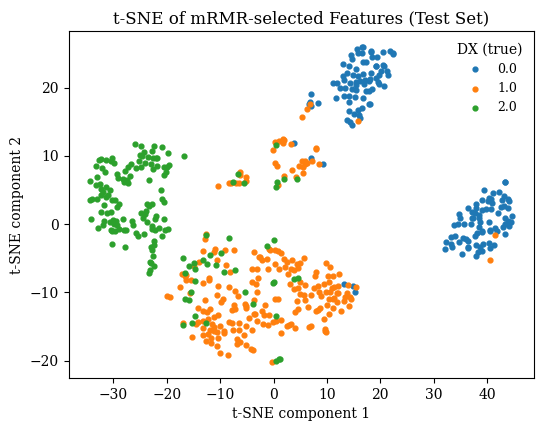

In [4]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib import rcParams

# ---------- Journal-friendly PDF output ----------
rcParams["pdf.fonttype"] = 42   # embed TrueType fonts in PDF
rcParams["ps.fonttype"] = 42
rcParams["font.family"] = "serif"
rcParams["font.size"] = 10

# Create folder for saving figures
SAVE_DIR = "figures"
os.makedirs(SAVE_DIR, exist_ok=True)

# Predict on test set using classification model (ensure cls, X_test_dx_s exist)
y_test_dx_pred = cls.predict(X_test_dx_s)

# t-SNE on the exact standardized test features seen by the classifier
tsne = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    random_state=42,
    perplexity=30
)
X_embedded = tsne.fit_transform(X_test_dx_s)

# Plot t-SNE result colored by TRUE DX labels
fig, ax = plt.subplots(figsize=(6, 4.5))
classes = np.unique(y_dx_test_enc)

for lab in classes:
    idx = (y_dx_test_enc == lab)
    ax.scatter(
        X_embedded[idx, 0],
        X_embedded[idx, 1],
        s=12,
        label=le.inverse_transform([lab])[0]  # readable class name
    )

ax.set_title("t-SNE of mRMR-selected Features (Test Set)")
ax.set_xlabel("t-SNE component 1")
ax.set_ylabel("t-SNE component 2")
ax.legend(title="DX (true)", fontsize=9, frameon=False)

# Save vector PDF and also show inline
pdf_path_tsne = os.path.join(SAVE_DIR, "mlp_tsne_dx_test.pdf")
fig.savefig(pdf_path_tsne, format="pdf", bbox_inches="tight")
print(f"[Saved] {pdf_path_tsne}")

plt.show()



In [5]:
def get_latest_state_for_rid(df, rid, id_col="RID", time_col="Month"):
    """Return the last (latest month) row for a given RID; None if not found."""
    sub = df[df[id_col] == rid]
    if sub.empty: return None
    return sub.sort_values(time_col).iloc[-1]

def build_feature_row_from_state(state_row, X_columns_t, dt_value):
    """
    Build a single feature row matching the training schema (columns ending with *_t plus dt).
    - For each feature ending with '_t', copy the value from the current state using its base name.
    - Fill missing with NaN; dt is set to the given horizon.
    """
    x = {}
    for c in X_columns_t:
        if c.endswith("_t"):
            base = c[:-2]
            x[c] = state_row.get(base, np.nan)
        else:
            x[c] = np.nan
    x["dt"] = dt_value
    return pd.Series(x)

def simulate_digital_twin(df_raw, rid, horizon_list=[6,12],
                          id_col="RID", time_col="Month",
                          target_mmse="MMSE", target_dx="DX"):
    """
    Simulate a subject's future states using the trained MLP models (regression + classification).
    Steps:
      1) Get the subject's latest observed state.
      2) Build the feature schema consistent with training (columns *_t + dt).
      3) Roll forward over horizons; at each step:
         - Build feature row from the current state.
         - Select mRMR Top-10 features for regression/classification and fill NaNs with train means.
         - Standardize with training scalers.
         - Predict MMSE and DX (with probabilities if available).
         - Append outputs and update the state (recursive rollout).
    Returns:
      pandas.DataFrame with columns: [RID, DeltaMonths, MMSE_hat, DX_hat, DX_proba]
    """
    # 1) Latest observation
    last_row = get_latest_state_for_rid(df_raw, rid, id_col, time_col)
    if last_row is None:
        raise ValueError(f"RID={rid} not found")

    # 2) Feature column schema (same as X_all used for training: *_t + dt)
    X_columns_t = X_all.columns.tolist()

    # 3) Recursive rollout
    cur_state = last_row.copy()
    outputs = []
    for h in horizon_list:
        feat_row = build_feature_row_from_state(cur_state, X_columns_t, dt_value=h)

        # Use mRMR Top-10 for each task; fill missing with training means
        X_mmse_one = pd.DataFrame([feat_row])[sel_mmse].fillna(X_train_mmse.mean(axis=0))
        X_dx_one   = pd.DataFrame([feat_row])[sel_dx].fillna(X_train_dx.mean(axis=0))

        # Standardize
        X_mmse_one_s = scaler_reg.transform(X_mmse_one)
        X_dx_one_s   = scaler_cls.transform(X_dx_one)

        # Predict
        mmse_pred = float(reg.predict(X_mmse_one_s)[0])
        if hasattr(cls, "predict_proba"):
            dx_proba = cls.predict_proba(X_dx_one_s)[0]
        else:
            # Fallback if classifier lacks predict_proba (rare)
            logits = cls.decision_function(X_dx_one_s)
            exps = np.exp(logits - np.max(logits))
            dx_proba = exps / exps.sum()

        dx_idx = int(cls.predict(X_dx_one_s)[0])
        dx_val = le.inverse_transform([dx_idx])[0]

        outputs.append({
            "RID": rid,
            "DeltaMonths": h,
            "MMSE_hat": mmse_pred,
            "DX_hat": dx_val,
            "DX_proba": dx_proba.tolist()
        })

        # Recursive state update
        cur_state[target_mmse] = mmse_pred
        cur_state[target_dx]   = dx_val

    return pd.DataFrame(outputs)


[Saved] figures\patient_22_history_forecast.pdf


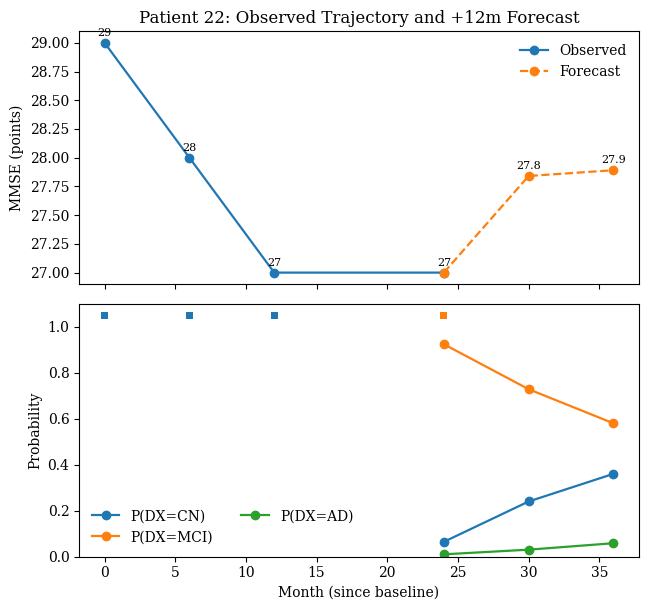

In [6]:
# =========================================
# Plot: Patient's observed history + forecast after last observation
# (journal-friendly: vector PDF, clear labels, no flashy options)
# =========================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ---- Journal-friendly PDF defaults (AI in Medicine) ----
rcParams["pdf.fonttype"] = 42   # embed TrueType fonts in PDF
rcParams["ps.fonttype"]  = 42
rcParams["font.family"]  = "serif"
rcParams["font.size"]    = 10

# ==== Change only these three lines ====
RID_TO_PLOT    = 22    # Patient RID to visualize
FUTURE_HORIZON = 12     # months ahead to forecast from the last observation
STEP_MONTHS    = 6      # forecast step size (e.g., roll every 6 months)

ID_COL, TIME_COL = "RID", "Month"
TARGET_MMSE, TARGET_DX = "MMSE", "DX"

# Directory for figures
SAVE_DIR = "figures"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------- Utility functions -------
def get_latest_state_for_rid(df, rid, id_col="RID", time_col="Month"):
    """Return the latest record for a given RID."""
    sub = df[df[id_col] == rid]
    if sub.empty:
        return None
    return sub.sort_values(time_col).iloc[-1]

def build_feature_row_from_state(state_row, X_columns_t, dt_value):
    """Build a single feature row from a given patient state and dt."""
    x = {}
    for c in X_columns_t:
        if c.endswith("_t"):
            base = c[:-2]
            x[c] = state_row.get(base, np.nan)
        else:
            x[c] = np.nan
    x["dt"] = dt_value
    return pd.Series(x)

def predict_one_step_from_state(state_row, dt_value):
    """
    Predict one step ahead using the current state + given dt.
    Returns (mmse_hat, proba[classes], dx_label).
    Assumes global objects exist: X_all, sel_mmse, sel_dx,
    X_train_mmse, X_train_dx, scaler_reg, scaler_cls, reg, cls, le.
    """
    X_columns_t = X_all.columns.tolist()
    feat_row = build_feature_row_from_state(state_row, X_columns_t, dt_value)
    X_mmse_one = pd.DataFrame([feat_row])[sel_mmse].fillna(X_train_mmse.mean(axis=0))
    X_dx_one   = pd.DataFrame([feat_row])[sel_dx].fillna(X_train_dx.mean(axis=0))
    X_mmse_one_s = scaler_reg.transform(X_mmse_one)
    X_dx_one_s   = scaler_cls.transform(X_dx_one)

    mmse_pred = float(reg.predict(X_mmse_one_s)[0])
    if hasattr(cls, "predict_proba"):
        dx_proba = cls.predict_proba(X_dx_one_s)[0]
    else:
        logits = cls.decision_function(X_dx_one_s)
        exps = np.exp(logits - np.max(logits))
        dx_proba = (exps / exps.sum()).ravel()
    dx_idx = int(cls.predict(X_dx_one_s)[0])
    dx_val = le.inverse_transform([dx_idx])[0]
    return mmse_pred, dx_proba, dx_val

# ------- Extract observed history for the patient -------
sub = df[df[ID_COL] == RID_TO_PLOT].sort_values(TIME_COL).copy()
if sub.empty:
    raise ValueError(f"RID={RID_TO_PLOT} not found")

months_hist = sub[TIME_COL].values.astype(float)
mmse_hist   = sub[TARGET_MMSE].values.astype(float)
# If DX in df is encoded integers (0..C-1), keep as numbers; else becomes NaN
dx_hist_raw = pd.to_numeric(sub[TARGET_DX], errors="coerce").values

# ------- Forecast after the last observation -------
last_row   = sub.iloc[-1].copy()
last_month = float(last_row[TIME_COL])

# Current point (Δt=0) probabilities (MMSE from observed)
mmse_now = float(last_row[TARGET_MMSE]) if pd.notna(last_row[TARGET_MMSE]) else np.nan
_, proba_now, dx_now_pred = predict_one_step_from_state(last_row, dt_value=0)

# Future steps, e.g., [6, 12]
future_dts = list(range(STEP_MONTHS, FUTURE_HORIZON + 1, STEP_MONTHS))

# Recursive roll-forward
future_months_abs = []
future_mmse_hat   = []
future_dx_proba   = []
cur_state = last_row.copy()

for dt in future_dts:
    mmse_pred, dx_proba, dx_val = predict_one_step_from_state(cur_state, dt_value=dt)
    future_months_abs.append(last_month + dt)
    future_mmse_hat.append(mmse_pred)
    future_dx_proba.append(dx_proba.tolist())
    # Update state for next iteration
    cur_state[TARGET_MMSE] = mmse_pred
    cur_state[TARGET_DX]   = dx_val

future_dx_proba = np.array(future_dx_proba) if len(future_dx_proba) > 0 else np.empty((0,0))
class_ids   = np.arange(len(le.classes_))
class_names = np.array(["CN", "MCI", "AD"])

# ------- Plot (publication-ready; minimal styling) -------
fig, axes = plt.subplots(2, 1, figsize=(6.5, 6.2), sharex=True)

# (Top) MMSE: Observed + Forecast
axes[0].plot(months_hist, mmse_hist, marker='o', linewidth=1.6, label="Observed")
if len(future_months_abs) > 0:
    axes[0].plot([last_month] + future_months_abs,
                 [mmse_now] + future_mmse_hat,
                 linestyle='--', marker='o', linewidth=1.6, label="Forecast")

# (optional) annotate values; keep subtle to avoid clutter
for m, y in zip(months_hist, mmse_hist):
    if np.isfinite(y):
        axes[0].annotate(f"{y:.0f}", (m, y), textcoords="offset points", xytext=(0, 5),
                         ha='center', fontsize=8)
if len(future_months_abs) > 0:
    for m, y in zip(future_months_abs, future_mmse_hat):
        if np.isfinite(y):
            axes[0].annotate(f"{y:.1f}", (m, y), textcoords="offset points", xytext=(0, 5),
                             ha='center', fontsize=8)

axes[0].set_ylabel("MMSE (points)")
axes[0].set_title(f"Patient {RID_TO_PLOT}: Observed Trajectory and +{FUTURE_HORIZON}m Forecast")
axes[0].legend(frameon=False, loc='best')

# Build proba arrays including Δt=0
if len(future_months_abs) > 0:
    proba_all = np.vstack([proba_now.reshape(1, -1), future_dx_proba])  # shape [H+1, C]
    months_all = np.array([last_month] + future_months_abs)
else:
    proba_all = proba_now.reshape(1, -1)
    months_all = np.array([last_month])

# (Bottom) DX probabilities
line_handles = []
for i, cname in enumerate(class_names):
    if proba_all.shape[1] == 0:  # safety
        continue
    h, = axes[1].plot(months_all, proba_all[:, i], marker='o', linewidth=1.6,
                      label=f"P(DX={cname})")
    line_handles.append(h)

axes[1].set_xlabel("Month (since baseline)")
axes[1].set_ylabel("Probability")
axes[1].set_ylim(0, 1.1)
axes[1].legend(ncol=2, frameon=False, loc='best')

# Observed DX markers (small squares at y=1.05), using the same colors as lines
line_colors = [h.get_color() for h in line_handles]
y_obs = 1.05
for m, dxv in zip(months_hist, dx_hist_raw):
    if np.isfinite(dxv):
        enc = int(dxv)
        if 0 <= enc < len(line_colors):
            axes[1].scatter([m], [y_obs], marker='s', s=24,
                            color=line_colors[enc], edgecolors='none')

plt.tight_layout()

# ---- Save vector PDF and also show inline in Jupyter ----
pdf_path = os.path.join(SAVE_DIR, f"patient_{RID_TO_PLOT}_history_forecast.pdf")
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"[Saved] {pdf_path}")
plt.show()


In [7]:
# =========================================
# MLP-only Ablations with 95% CIs
# (a) with mRMR vs w/o mRMR (all numeric)
# (b) static-only vs dynamic-only (dt counted as dynamic)
# Static/Dynamic split uses RULE-BASED method (your patterns/whitelist)
# =========================================

import re
import numpy as np, pandas as pd
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (accuracy_score, f1_score, mean_absolute_error,
                             mean_squared_error, roc_auc_score)

# ---------- Safety checks: rely on your previous cells ----------
needed = ["X_train_raw","X_val_raw","X_test_raw",
          "y_dx_train_enc","y_dx_val_enc","y_dx_test_enc",
          "y_mmse_train_raw","y_mmse_val_raw","y_mmse_test_raw",
          "sel_dx","sel_mmse","rid_test","pairs","valid_idx","rid_series_all",
          "MLP_CLS_PARAMS","MLP_REG_PARAMS","SEED"]
for v in needed:
    assert v in globals(), f"Missing `{v}` – please run earlier cells."

# ---------- Helpers ----------
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

if "labels_order" not in globals():
    labels_order = np.unique(y_dx_train_enc)

def reorder_proba_to_labels(proba, model_classes, labels):
    """Align predict_proba columns to the global label order."""
    col_map = {c:i for i,c in enumerate(model_classes)}
    out = np.zeros((proba.shape[0], len(labels)))
    for j, lab in enumerate(labels):
        out[:, j] = proba[:, col_map[lab]] if lab in col_map else 0.0
    return out

def safe_multiclass_auc(y_true, proba, labels):
    """Macro AUC (OVR); returns NaN if not computable."""
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return float(roc_auc_score(y_true, proba, average="macro",
                                   multi_class="ovr", labels=labels))
    except Exception:
        return np.nan

def subj_boot_ci_indices(rid_vec, seed=SEED, n_boot=1000):
    """Yield index arrays by resampling subject blocks (RID) with replacement."""
    rng = np.random.default_rng(seed)
    mp = {}
    for i, r in enumerate(rid_vec):
        mp.setdefault(r, []).append(i)
    subs = np.array(list(mp.keys()))
    blocks = [np.asarray(mp[s], int) for s in subs]
    for _ in range(n_boot):
        pick = rng.choice(len(blocks), size=len(blocks), replace=True)
        idx  = np.concatenate([blocks[i] for i in pick])
        yield idx

def ci_regression(y_true, y_pred, rid_vec, n_boot=1000):
    rmses, maes = [], []
    for idx in subj_boot_ci_indices(rid_vec, n_boot=n_boot):
        yt, yp = y_true[idx], y_pred[idx]
        rmses.append(rmse(yt, yp))
        maes.append(mean_absolute_error(yt, yp))
    def _ci(a):
        lo, hi = np.percentile(a, [2.5,97.5])
        return float(np.mean(a)), float(lo), float(hi)
    return _ci(rmses), _ci(maes)

def ci_classification(y_true, y_pred, proba, labels, rid_vec, n_boot=1000):
    accs, f1s, aucs = [], [], []
    for idx in subj_boot_ci_indices(rid_vec, n_boot=n_boot):
        yt, yp, pp = y_true[idx], y_pred[idx], proba[idx]
        accs.append(accuracy_score(yt, yp))
        f1s.append(f1_score(yt, yp, average="macro", zero_division=0))
        aucs.append(safe_multiclass_auc(yt, pp, labels))
    def _ci(a):
        a = np.asarray(a, float); a = a[~np.isnan(a)]
        if len(a)==0:
            return (np.nan, np.nan, np.nan)
        lo, hi = np.percentile(a, [2.5,97.5])
        return float(np.mean(a)), float(lo), float(hi)
    return _ci(accs), _ci(aucs), _ci(f1s)

def fmt_ci(mean, lo, hi, k=3):
    if any([x!=x for x in [mean,lo,hi]]):
        return "NA"
    return f"{mean:.{k}f} [{lo:.{k}f}, {hi:.{k}f}]"

def build_sets_from_feats(feat_cols, Xtr_raw, Xv_raw, Xte_raw):
    """Impute by training means on selected features, then standardize."""
    vals = Xtr_raw[feat_cols].mean()
    Xtr = Xtr_raw[feat_cols].fillna(vals)
    Xv  = Xv_raw[feat_cols].fillna(vals)
    Xte = Xte_raw[feat_cols].fillna(vals)
    scaler = StandardScaler()
    return scaler.fit_transform(Xtr), scaler.transform(Xv), scaler.transform(Xte)

def train_mlp_cls(Xtr, ytr):
    """MLPClassifier with sample_weight (class-balanced), consistent with earlier cells."""
    clf = MLPClassifier(**MLP_CLS_PARAMS)
    cc = Counter(ytr); total = sum(cc.values())
    cw = {c: total/(len(cc)*n) for c,n in cc.items()}
    sw = np.array([cw[c] for c in ytr], float)
    try:
        clf.fit(Xtr, ytr, sample_weight=sw)
    except TypeError:
        clf.fit(Xtr, ytr)
    return clf

# ---------- RULE-BASED Static/Dynamic split (your method) ----------
# You can edit these three items to match your feature inventory notebook exactly:
EXCLUDE_FROM_MODEL = {"MMSE", "DX"}   # supervised targets excluded from static judgement
STATIC_EXACTS = {
    "AGE", "SITE", "PTGENDER", "PTEDUCAT", "PTETHCAT", "PTRACCAT",
    "PTMARRY", "ICV", "ICV_BL"
}
STATIC_PATTERNS = [
    r"^APOE.*",     # APOE genotype
    r".*EDUC.*",    # education related
    r".*_bl$",      # baseline variables (unless explicitly excluded)
]

def is_static(col_base: str) -> bool:
    """Decide whether a BASE-NAME feature is static across time by rules."""
    u = col_base.upper()
    if u in {x.upper() for x in EXCLUDE_FROM_MODEL}:
        return False
    if u in {x.upper() for x in STATIC_EXACTS}:
        return True
    return any(re.match(pat, col_base, flags=re.IGNORECASE) for pat in STATIC_PATTERNS)

# We split on the CURRENT modeling columns (X_*_raw), which are numeric and mainly of form <base>_t plus 'dt'
all_numeric_cols = list(X_train_raw.columns)
# Map training cols to base-names: '<base>_t' -> '<base>', 'dt' -> 'dt'
base_names = []
for c in all_numeric_cols:
    if c.endswith("_t"):
        base_names.append(c[:-2])
    else:
        base_names.append(c)
# preserve order, unique
base_names = list(dict.fromkeys(base_names))

# Apply rules on base-names (force dt into dynamic)
static_basenames  = [b for b in base_names if b != "dt" and is_static(b)]
dynamic_basenames = [b for b in base_names if b != "dt" and not is_static(b)]

def to_t_cols(basenames):
    cols = []
    for b in basenames:
        ct = f"{b}_t"
        if ct in all_numeric_cols:
            cols.append(ct)
        elif b in all_numeric_cols:  # fallback (in case some column isn't suffixed)
            cols.append(b)
    return cols

static_cols  = to_t_cols(static_basenames)
dynamic_cols = to_t_cols(dynamic_basenames)
if "dt" in all_numeric_cols and "dt" not in dynamic_cols:
    dynamic_cols.append("dt")

print(f"[Rule-based split] static={len(static_cols)}  dynamic={len(dynamic_cols)} (dt in dynamic: {'dt' in dynamic_cols})")

# ---------- Feature sets for ablation ----------
feats_dx_mrmr   = sel_dx
feats_mmse_mrmr = sel_mmse
feats_dx_all    = all_numeric_cols
feats_mmse_all  = all_numeric_cols

# ---------- Build datasets ----------
# DX
Xtr_dx_mrmr_s, Xv_dx_mrmr_s, Xte_dx_mrmr_s = build_sets_from_feats(feats_dx_mrmr,   X_train_raw, X_val_raw, X_test_raw)
Xtr_dx_all_s,  Xv_dx_all_s,  Xte_dx_all_s  = build_sets_from_feats(feats_dx_all,    X_train_raw, X_val_raw, X_test_raw)
Xtr_dx_stat_s, Xv_dx_stat_s, Xte_dx_stat_s = build_sets_from_feats(static_cols,     X_train_raw, X_val_raw, X_test_raw) if len(static_cols)>0 else (None,None,None)
Xtr_dx_dyn_s,  Xv_dx_dyn_s,  Xte_dx_dyn_s  = build_sets_from_feats(dynamic_cols,    X_train_raw, X_val_raw, X_test_raw) if len(dynamic_cols)>0 else (None,None,None)

# MMSE
Xtr_mm_mrmr_s, Xv_mm_mrmr_s, Xte_mm_mrmr_s = build_sets_from_feats(feats_mmse_mrmr, X_train_raw, X_val_raw, X_test_raw)
Xtr_mm_all_s,  Xv_mm_all_s,  Xte_mm_all_s  = build_sets_from_feats(feats_mmse_all,  X_train_raw, X_val_raw, X_test_raw)
Xtr_mm_stat_s, Xv_mm_stat_s, Xte_mm_stat_s = build_sets_from_feats(static_cols,     X_train_raw, X_val_raw, X_test_raw) if len(static_cols)>0 else (None,None,None)
Xtr_mm_dyn_s,  Xv_mm_dyn_s,  Xte_mm_dyn_s  = build_sets_from_feats(dynamic_cols,    X_train_raw, X_val_raw, X_test_raw) if len(dynamic_cols)>0 else (None,None,None)

# ---------- Train MLPs ----------
# DX
mlp_dx_mrmr = train_mlp_cls(Xtr_dx_mrmr_s, y_dx_train_enc)
mlp_dx_all  = train_mlp_cls(Xtr_dx_all_s,  y_dx_train_enc)
mlp_dx_stat = train_mlp_cls(Xtr_dx_stat_s, y_dx_train_enc) if Xtr_dx_stat_s is not None else None
mlp_dx_dyn  = train_mlp_cls(Xtr_dx_dyn_s,  y_dx_train_enc) if Xtr_dx_dyn_s  is not None else None

# MMSE
reg_mm_mrmr = MLPRegressor(**MLP_REG_PARAMS).fit(Xtr_mm_mrmr_s, y_mmse_train_raw)
reg_mm_all  = MLPRegressor(**MLP_REG_PARAMS).fit(Xtr_mm_all_s,  y_mmse_train_raw)
reg_mm_stat = MLPRegressor(**MLP_REG_PARAMS).fit(Xtr_mm_stat_s, y_mmse_train_raw) if Xtr_mm_stat_s is not None else None
reg_mm_dyn  = MLPRegressor(**MLP_REG_PARAMS).fit(Xtr_mm_dyn_s,  y_mmse_train_raw) if Xtr_mm_dyn_s  is not None else None

# ---------- Evaluate (DX) ----------
def eval_dx_row(name, clf, Xte):
    pred  = clf.predict(Xte)
    proba = reorder_proba_to_labels(clf.predict_proba(Xte), clf.classes_, labels_order)
    acc_ci, auc_ci, f1_ci = ci_classification(y_dx_test_enc, pred, proba, labels_order, rid_test, n_boot=1000)
    return {"Setting": name,
            "ACC": fmt_ci(*acc_ci),
            "AUC (macro-OVR)": fmt_ci(*auc_ci),
            "Macro-F1": fmt_ci(*f1_ci),
            "N_test": len(y_dx_test_enc),
            "Subjects_test": len(np.unique(rid_test))}

rows_dx = []
rows_dx.append(eval_dx_row("MLP + mRMR (K=TOPK_DX)", mlp_dx_mrmr, Xte_dx_mrmr_s))
rows_dx.append(eval_dx_row("MLP w/o mRMR (all numeric)", mlp_dx_all,  Xte_dx_all_s))
if mlp_dx_stat is not None:
    rows_dx.append(eval_dx_row("MLP (static-only)",  mlp_dx_stat, Xte_dx_stat_s))
if mlp_dx_dyn is not None:
    rows_dx.append(eval_dx_row("MLP (dynamic-only, +dt)", mlp_dx_dyn,  Xte_dx_dyn_s))

df_ablate_dx_mlp = pd.DataFrame(rows_dx, columns=["Setting","ACC","AUC (macro-OVR)","Macro-F1","N_test","Subjects_test"])
display(df_ablate_dx_mlp)
df_ablate_dx_mlp.to_csv("ablation_MLP_DX.csv", index=False, encoding="utf-8-sig")
print("Saved: ablation_MLP_DX.csv")

# ---------- Evaluate (MMSE) ----------
def eval_mm_row(name, reg, Xte):
    pred = reg.predict(Xte)
    rmse_ci, mae_ci = ci_regression(y_mmse_test_raw.values, pred, rid_test, n_boot=1000)
    return {"Setting": name,
            "RMSE": fmt_ci(*rmse_ci),
            "MAE":  fmt_ci(*mae_ci),
            "N_test": len(y_mmse_test_raw),
            "Subjects_test": len(np.unique(rid_test))}

rows_mm = []
rows_mm.append(eval_mm_row("MLP + mRMR (K=TOPK_MMSE)", reg_mm_mrmr, Xte_mm_mrmr_s))
rows_mm.append(eval_mm_row("MLP w/o mRMR (all numeric)", reg_mm_all,  Xte_mm_all_s))
if reg_mm_stat is not None:
    rows_mm.append(eval_mm_row("MLP (static-only)",  reg_mm_stat, Xte_mm_stat_s))
if reg_mm_dyn is not None:
    rows_mm.append(eval_mm_row("MLP (dynamic-only, +dt)", reg_mm_dyn,  Xte_mm_dyn_s))

df_ablate_mmse_mlp = pd.DataFrame(rows_mm, columns=["Setting","RMSE","MAE","N_test","Subjects_test"])
display(df_ablate_mmse_mlp)
df_ablate_mmse_mlp.to_csv("ablation_MLP_MMSE.csv", index=False, encoding="utf-8-sig")
print("Saved: ablation_MLP_MMSE.csv")

print(f"\n[Summary] #static cols: {len(static_cols)} | #dynamic cols: {len(dynamic_cols)} | dt in dynamic: {'dt' in dynamic_cols}")


[Rule-based split] static=27  dynamic=359 (dt in dynamic: True)


,Setting,ACC,AUC (macro-OVR),Macro-F1,N_test,Subjects_test
0,MLP + mRMR (K=TOPK_DX),"0.888 [0.836, 0.934]","0.972 [0.953, 0.989]","0.876 [0.818, 0.928]",556,152
1,MLP w/o mRMR (all numeric),"0.705 [0.632, 0.770]","0.861 [0.818, 0.902]","0.695 [0.624, 0.760]",556,152
2,MLP (static-only),"0.703 [0.632, 0.776]","0.861 [0.819, 0.902]","0.656 [0.585, 0.732]",556,152
3,"MLP (dynamic-only, +dt)","0.744 [0.678, 0.816]","0.874 [0.830, 0.915]","0.729 [0.661, 0.798]",556,152


Saved: ablation_MLP_DX.csv


,Setting,RMSE,MAE,N_test,Subjects_test
0,MLP + mRMR (K=TOPK_MMSE),"2.400 [1.895, 2.913]","1.583 [1.301, 1.867]",556,152
1,MLP w/o mRMR (all numeric),"5.172 [4.545, 5.769]","4.140 [3.686, 4.641]",556,152
2,MLP (static-only),"4.227 [3.599, 4.872]","2.994 [2.520, 3.500]",556,152
3,"MLP (dynamic-only, +dt)","5.649 [4.960, 6.392]","4.621 [4.121, 5.157]",556,152


Saved: ablation_MLP_MMSE.csv

[Summary] #static cols: 27 | #dynamic cols: 359 | dt in dynamic: True


In [8]:
# =========================================
# DX baselines on EXACT SAME mRMR features as MLP — VALIDATION SET
# =========================================
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# --- safety checks: reuse SAME artifacts (features + scaled matrices) ---
assert 'sel_dx' in globals(), "sel_dx not found. Make sure mRMR step has run."
for v in ["X_train_dx_s","X_val_dx_s","y_dx_train_enc","y_dx_val_enc","rid_series_all"]:
    assert v in globals(), f"Missing `{v}`; run previous steps."

# --- derive rid_val vector for subject-level bootstrap ---
if 'rid_val' in globals():
    rid_val_vec = np.asarray(rid_val)
elif 'valid_idx' in globals():
    rid_val_vec = np.asarray(rid_series_all.iloc[valid_idx].values)
elif 'mask_val' in globals():
    rid_val_vec = np.asarray(rid_series_all[mask_val].reset_index(drop=True).values)
else:
    raise AssertionError("Need rid_val or valid_idx or mask_val to build rid_val_vec.")

labels_order = np.unique(y_dx_train_enc)

def _reorder_proba(proba, model_classes, ref_labels):
    col_map = {c:i for i,c in enumerate(model_classes)}
    out = np.zeros((proba.shape[0], len(ref_labels)), dtype=float)
    for j, lab in enumerate(ref_labels):
        if lab in col_map:
            out[:, j] = proba[:, col_map[lab]]
    return out

def _safe_macro_auc(y_true, proba, labels):
    try:
        if np.unique(y_true).size < 2:
            return np.nan
        return roc_auc_score(y_true, proba, average="macro", multi_class="ovr", labels=labels)
    except Exception:
        return np.nan

def _subject_boot_ci(y_true, y_pred, proba, rid_vec, labels, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    # group indices by subject id
    rid_to_idx = {}
    for i, r in enumerate(rid_vec):
        rid_to_idx.setdefault(r, []).append(i)
    uniq = np.array(list(rid_to_idx.keys()))
    B = n_boot
    accs, f1s, aucs = np.empty(B), np.empty(B), np.empty(B)
    for b in range(B):
        boot_rids = rng.choice(uniq, size=len(uniq), replace=True)
        idx = np.concatenate([rid_to_idx[r] for r in boot_rids]).astype(int)
        yt, yp = y_true[idx], y_pred[idx]
        pp = proba[idx]
        accs[b] = accuracy_score(yt, yp)
        f1s[b]  = f1_score(yt, yp, average="macro", zero_division=0)
        aucs[b] = _safe_macro_auc(yt, pp, labels)
    def _ci(a):
        a = a[~np.isnan(a)]
        if a.size == 0: return (np.nan, np.nan, np.nan)
        lo, hi = np.percentile(a, [2.5, 97.5])
        return (float(a.mean()), float(lo), float(hi))
    return _ci(accs), _ci(f1s), _ci(aucs)

def _fmt(point, lo, hi): 
    return "NA" if any(map(lambda x: x!=x, [point,lo,hi])) else f"{point:.3f} [{lo:.3f}, {hi:.3f}]"

# --- 0) MLP classifier object (reuse if available; otherwise retrain same params) ---
if 'cls' in globals():
    mlp = cls
elif 'mlp_dx_mrmr' in globals():
    mlp = mlp_dx_mrmr
else:
    from sklearn.neural_network import MLPClassifier
    assert 'MLP_CLS_PARAMS' in globals() and 'SEED' in globals(), "Need MLP_CLS_PARAMS and SEED."
    mlp = MLPClassifier(**MLP_CLS_PARAMS).fit(X_train_dx_s, y_dx_train_enc)

# --- 1) MLP (ours) ---
pred_mlp  = mlp.predict(X_val_dx_s)
proba_mlp = _reorder_proba(mlp.predict_proba(X_val_dx_s), mlp.classes_, labels_order)

# --- 2) Logistic Regression (multinomial, balanced) ---
try:
    lr = LogisticRegression(
        solver="saga", penalty="l2", class_weight="balanced",
        max_iter=5000, random_state=SEED, multi_class="multinomial"
    ).fit(X_train_dx_s, y_dx_train_enc)
except Exception as e:
    print("[LogReg] Fallback to lbfgs:", e)
    lr = LogisticRegression(
        solver="lbfgs", penalty="l2", class_weight="balanced",
        max_iter=2000, random_state=SEED, multi_class="multinomial"
    ).fit(X_train_dx_s, y_dx_train_enc)
pred_lr  = lr.predict(X_val_dx_s)
proba_lr = _reorder_proba(lr.predict_proba(X_val_dx_s), lr.classes_, labels_order)

# --- 3) Random Forest (balanced) ---
rf = RandomForestClassifier(
    n_estimators=500, class_weight="balanced_subsample",
    n_jobs=-1, random_state=SEED
).fit(X_train_dx_s, y_dx_train_enc)
pred_rf  = rf.predict(X_val_dx_s)
proba_rf = _reorder_proba(rf.predict_proba(X_val_dx_s), rf.classes_, labels_order)

# --- 4) Decision Tree (balanced) ---
dt = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=None,
    min_samples_leaf=5,
    random_state=SEED
).fit(X_train_dx_s, y_dx_train_enc)
pred_dt  = dt.predict(X_val_dx_s)
proba_dt = _reorder_proba(dt.predict_proba(X_val_dx_s), dt.classes_, labels_order)

# --- 5) Subject-level bootstrap CIs on VALIDATION set (for model selection only) ---
rows_compact, rows_numeric = [], []
for name, yp, pp in [
    ("MLP (ours)",          pred_mlp, proba_mlp),
    ("Logistic Regression", pred_lr,  proba_lr),
    ("Random Forest",       pred_rf,  proba_rf),
    ("Decision Tree",       pred_dt,  proba_dt),
]:
    # point estimates (on VAL)
    acc_pt = accuracy_score(y_dx_val_enc, yp)
    f1_pt  = f1_score(y_dx_val_enc, yp, average="macro", zero_division=0)
    auc_pt = _safe_macro_auc(y_dx_val_enc, pp, labels_order)
    # 95% CIs via RID-block bootstrap
    (acc_m, acc_lo, acc_hi), (f1_m, f1_lo, f1_hi), (auc_m, auc_lo, auc_hi) = \
        _subject_boot_ci(y_dx_val_enc, yp, pp, rid_val_vec, labels_order, n_boot=1000, seed=SEED)
    rows_compact.append({
        "Model": name,
        "ACC (point [95% CI])": _fmt(acc_pt, acc_lo, acc_hi),
        "Macro-F1 (point [95% CI])": _fmt(f1_pt,  f1_lo,  f1_hi),
        "Macro-AUC (OVR) [95% CI]": _fmt(auc_pt,  auc_lo, auc_hi),
        "N_val": int(len(y_dx_val_enc)),
        "Subjects_val": int(len(np.unique(rid_val_vec))),
    })
    rows_numeric.append({
        "Model": name,
        "ACC_point": acc_pt, "ACC_CI_low": acc_lo, "ACC_CI_high": acc_hi,
        "F1_point":  f1_pt,  "F1_CI_low":  f1_lo,  "F1_CI_high":  f1_hi,
        "AUC_point": auc_pt, "AUC_CI_low": auc_lo, "AUC_CI_high": auc_hi,
        "N_val": int(len(y_dx_val_enc)),
        "Subjects_val": int(len(np.unique(rid_val_vec))),
    })

df_dx_val_compact = pd.DataFrame(rows_compact, columns=[
    "Model","ACC (point [95% CI])","Macro-F1 (point [95% CI])","Macro-AUC (OVR) [95% CI]","N_val","Subjects_val"
])
df_dx_val_numeric = pd.DataFrame(rows_numeric, columns=[
    "Model","ACC_point","ACC_CI_low","ACC_CI_high",
    "F1_point","F1_CI_low","F1_CI_high",
    "AUC_point","AUC_CI_low","AUC_CI_high",
    "N_val","Subjects_val"
])

# --- 6) Save validation tables for the paper's ablation/model-selection section ---
os.makedirs("tables", exist_ok=True)
compact_path = "tables/dx_baselines_val_compact.csv"
numeric_path = "tables/dx_baselines_val_numeric.csv"
df_dx_val_compact.to_csv(compact_path, index=False, encoding="utf-8-sig")
df_dx_val_numeric.to_csv(numeric_path, index=False, encoding="utf-8-sig")
print(f"[Saved] {compact_path}")
print(f"[Saved] {numeric_path}")

try:
    from IPython.display import display
    print("\n=== DX baselines on EXACT SAME mRMR features as MLP (Validation set) ===")
    display(df_dx_val_compact)
except Exception:
    pass


[Saved] tables/dx_baselines_val_compact.csv
[Saved] tables/dx_baselines_val_numeric.csv

=== DX baselines on EXACT SAME mRMR features as MLP (Validation set) ===


,Model,ACC (point [95% CI]),Macro-F1 (point [95% CI]),Macro-AUC (OVR) [95% CI],N_val,Subjects_val
0,MLP (ours),"0.936 [0.961, 1.000]","0.936 [0.870, 1.000]","0.984 [1.000, 1.000]",283,76
1,Logistic Regression,"0.940 [0.961, 1.000]","0.940 [0.889, 1.000]","0.983 [0.994, 1.000]",283,76
2,Random Forest,"0.919 [0.934, 1.000]","0.918 [0.825, 1.000]","0.981 [0.994, 1.000]",283,76
3,Decision Tree,"0.887 [0.855, 0.974]","0.888 [0.717, 0.951]","0.941 [0.935, 1.000]",283,76


In [9]:
# =========================================
# 12++) DX Calibration (separate FIGs & CSVs, EN labels)
#       - Outputs:
#         FIGs: DX_calib_top1_k10_en.(pdf|png)
#               DX_calib_classwise_k10_en.(pdf|png)
#         CSVs: DX_calibration_k10_metrics.csv
#               DX_calibration_k10_bins.csv
# =========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# --------- metrics helpers ----------
def multiclass_brier(y_true, y_prob):
    """Multiclass Brier score."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    K = y_prob.shape[1]
    onehot = np.eye(K)[y_true]
    return np.mean(np.sum((y_prob - onehot) ** 2, axis=1))

def _bin_edges(values, n_bins=10, strategy='equal_width'):
    """Compute bin edges for calibration."""
    values = np.asarray(values, dtype=float)
    if strategy == 'equal_freq':
        q = np.linspace(0, 1, n_bins + 1)
        edges = np.unique(np.quantile(values, q))
        if len(edges) - 1 < n_bins:
            edges = np.linspace(0, 1, n_bins + 1)
    else:
        edges = np.linspace(0, 1, n_bins + 1)
    return edges

def ece_toplabel(y_true, y_prob, n_bins=10, strategy='equal_width'):
    """
    Top-1 Expected Calibration Error (ECE) and Maximum Calibration Error (MCE)
    following Guo et al. (2017), with per-bin statistics.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    conf = y_prob.max(axis=1)
    pred = y_prob.argmax(axis=1)
    correct = (pred == y_true).astype(float)

    edges = _bin_edges(conf, n_bins, strategy)
    bin_id = np.digitize(conf, edges, right=True) - 1
    bin_id = np.clip(bin_id, 0, len(edges) - 2)

    N = len(y_true)
    ece = 0.0
    mce = 0.0
    stats = []

    for b in range(len(edges) - 1):
        idx = (bin_id == b)
        n_b = int(idx.sum())
        if n_b == 0:
            continue
        acc_b = float(correct[idx].mean())
        conf_b = float(conf[idx].mean())
        gap = abs(acc_b - conf_b)
        ece += (n_b / N) * gap
        mce = max(mce, gap)
        stats.append({
            'section': 'top1',
            'class': 'top1',
            'bin_left': float(edges[b]),
            'bin_right': float(edges[b + 1]),
            'n': n_b,
            'acc': acc_b,
            'conf': conf_b,
            'gap': gap
        })
    return ece, mce, stats

def ece_classwise(y_true, y_prob, class_names=None, n_bins=10, strategy='equal_width'):
    """
    Class-wise one-vs-rest Expected Calibration Error (ECE) and
    Maximum Calibration Error (MCE), reported as macro averages,
    with per-bin statistics.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    K = y_prob.shape[1]
    if class_names is None:
        class_names = [f"class {k}" for k in range(K)]

    stats_all = []
    eces, mces = [], []

    for k in range(K):
        pk = y_prob[:, k]
        yk = (y_true == k).astype(int)
        edges = _bin_edges(pk, n_bins, strategy)
        bin_id = np.digitize(pk, edges, right=True) - 1
        bin_id = np.clip(bin_id, 0, len(edges) - 2)

        N = len(yk)
        ece = 0.0
        mce = 0.0

        for b in range(len(edges) - 1):
            idx = (bin_id == b)
            n_b = int(idx.sum())
            if n_b == 0:
                continue
            acc_b = float(yk[idx].mean())
            conf_b = float(pk[idx].mean())
            gap = abs(acc_b - conf_b)
            ece += (n_b / N) * gap
            mce = max(mce, gap)
            stats_all.append({
                'section': 'classwise',
                'class': str(class_names[k]),
                'bin_left': float(edges[b]),
                'bin_right': float(edges[b + 1]),
                'n': n_b,
                'acc': acc_b,
                'conf': conf_b,
                'gap': gap
            })

        eces.append(ece)
        mces.append(mce)

    macro_ece = float(np.mean(eces)) if len(eces) else np.nan
    macro_mce = float(np.mean(mces)) if len(mces) else np.nan
    return macro_ece, macro_mce, stats_all

# --------- plotting ----------
def plot_top1_reliability(y_true, y_prob, n_bins=10, strategy='equal_width',
                          title="DX Top-1 Reliability (k=10)",
                          out_prefix="DX_calib_top1_k10_en"):
    """Generate and save the Top-1 reliability diagram (PDF & PNG)."""
    ece_tl, mce_tl, tl_stats = ece_toplabel(y_true, y_prob, n_bins, strategy)

    fig = plt.figure(figsize=(6, 4), dpi=300)
    ax = fig.add_subplot(1, 1, 1)
    ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1, label="Ideal y=x")

    if tl_stats:
        xs = [s['conf'] for s in tl_stats]
        ys = [s['acc'] for s in tl_stats]
        ns = [s['n'] for s in tl_stats]
        smin, smax = max(1, min(ns)), max(ns)
        sizes = [20 + 120 * (n - smin) / (smax - smin + 1e-9) for n in ns]
        ax.plot(xs, ys, marker='o', linewidth=1.2, label=f"Top-1 ({n_bins} bins)")
        ax.scatter(xs, ys, s=sizes, alpha=0.7)

    ax.set_xlabel("Mean confidence (max probability)")
    ax.set_ylabel("Top-1 accuracy")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}.pdf", bbox_inches="tight")
    plt.savefig(f"{out_prefix}.png", bbox_inches="tight")
    plt.close(fig)

    return {
        "ece_top1": ece_tl,
        "mce_top1": mce_tl,
        "outfile_pdf": f"{out_prefix}.pdf",
        "outfile_png": f"{out_prefix}.png"
    }

def plot_classwise_calibration(y_true, y_prob, class_names=None, n_bins=10, strategy='equal_width',
                               title="DX One-vs-Rest Calibration by Class",
                               out_prefix="DX_calib_classwise_k10_en"):
    """Generate and save the class-wise calibration curves (PDF & PNG)."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    K = y_prob.shape[1]
    if class_names is None:
        class_names = [f"class {k}" for k in range(K)]

    # Use sklearn uniform bins for reproducibility
    fig = plt.figure(figsize=(6.5, 4), dpi=300)
    ax = fig.add_subplot(1, 1, 1)

    for k in range(K):
        yk = (y_true == k).astype(int)
        pk = y_prob[:, k]
        prob_true, prob_pred = calibration_curve(
            yk, pk, n_bins=n_bins, strategy='uniform'
        )
        ax.plot(prob_pred, prob_true, marker='o', linewidth=1.2, label=str(class_names[k]))

    ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1, label="Ideal y=x")
    ax.set_xlabel("Model confidence (class probability)")
    ax.set_ylabel("Empirical frequency")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9, loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}.pdf", bbox_inches="tight")
    plt.savefig(f"{out_prefix}.png", bbox_inches="tight")
    plt.close(fig)

    return {
        "outfile_pdf": f"{out_prefix}.pdf",
        "outfile_png": f"{out_prefix}.png"
    }

# --------- main export wrapper ----------
def export_dx_calibration_separate(y_true, y_prob, class_names=None,
                                   n_bins=10, strategy='equal_width',
                                   metrics_csv="DX_calibration_k10_metrics.csv",
                                   bins_csv="DX_calibration_k10_bins.csv"):
    """
    Export DX calibration results:
    - Two separate figures (Top-1 and Class-wise)
    - One summary metrics CSV
    - One per-bin statistics CSV
    """
    import pandas as pd

    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    assert y_prob.ndim == 2 and len(y_true) == y_prob.shape[0]

    # Compute metrics
    brier = multiclass_brier(y_true, y_prob)
    ece_tl, mce_tl, tl_stats = ece_toplabel(y_true, y_prob, n_bins, strategy)
    ece_cw, mce_cw, cw_stats = ece_classwise(y_true, y_prob, class_names, n_bins, strategy)

    # Save figures
    fig_top1 = plot_top1_reliability(y_true, y_prob, n_bins, strategy)
    fig_cw = plot_classwise_calibration(y_true, y_prob, class_names, n_bins, strategy)

    # Save tables
    metrics_df = pd.DataFrame([{
        "Brier_multiclass": brier,
        "ECE_top1": ece_tl,
        "MCE_top1": mce_tl,
        "ECE_classwise_macro": ece_cw,
        "MCE_classwise_macro": mce_cw,
        "bins": n_bins,
        "strategy": strategy
    }])
    metrics_df.to_csv(metrics_csv, index=False, encoding="utf-8-sig")

    bins_df = pd.DataFrame(
        tl_stats + cw_stats,
        columns=["section", "class", "bin_left", "bin_right", "n", "acc", "conf", "gap"]
    )
    bins_df.to_csv(bins_csv, index=False, encoding="utf-8-sig")

    print(f"[Saved] {fig_top1['outfile_pdf']} | {fig_cw['outfile_pdf']} | {metrics_csv} | {bins_csv}")

    return {
        "brier": brier,
        "ece_top1": ece_tl,
        "mce_top1": mce_tl,
        "ece_classwise_macro": ece_cw,
        "mce_classwise_macro": mce_cw,
        "top1_pdf": fig_top1["outfile_pdf"],
        "classwise_pdf": fig_cw["outfile_pdf"],
        "metrics_csv": metrics_csv,
        "bins_csv": bins_csv
    }

# ===== Actual invocation (consistent with your variables) =====
y_true_cls = y_dx_test_enc
y_prob_cls = cls.predict_proba(X_test_dx_s)   # shape (N, 3)
class_names = [str(c) for c in le.classes_]

res_sep = export_dx_calibration_separate(
    y_true_cls,
    y_prob_cls,
    class_names=class_names,
    n_bins=10,
    strategy='equal_width',  # use 'equal_freq' if class imbalance is severe
    metrics_csv="DX_calibration_k10_metrics.csv",
    bins_csv="DX_calibration_k10_bins.csv"
)

print("\n[DX Calibration Separate Summary]")
print(res_sep)


[Saved] DX_calib_top1_k10_en.pdf | DX_calib_classwise_k10_en.pdf | DX_calibration_k10_metrics.csv | DX_calibration_k10_bins.csv

[DX Calibration Separate Summary]
{'brier': np.float64(0.14410865347811522), 'ece_top1': 0.038446443965260396, 'mce_top1': 0.5020395252282104, 'ece_classwise_macro': 0.029922315866167715, 'mce_classwise_macro': 0.3939391071286858, 'top1_pdf': 'DX_calib_top1_k10_en.pdf', 'classwise_pdf': 'DX_calib_classwise_k10_en.pdf', 'metrics_csv': 'DX_calibration_k10_metrics.csv', 'bins_csv': 'DX_calibration_k10_bins.csv'}


In [ ]:
# =========================================
# 0) Environment & Random Seed
# =========================================
import sys, subprocess
def pip_install(pkg):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# The package name for mRMR is mrmr-selection
pip_install("mrmr-selection")
pip_install("scikit-learn")
pip_install("pandas")
pip_install("numpy")

import numpy as np
import pandas as pd
import random
from collections import Counter

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             accuracy_score, f1_score, confusion_matrix,
                             classification_report)

from mrmr import mrmr_regression, mrmr_classif

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# =========================================
# 1) Parameters (modify as needed)
# =========================================
CSV_PATH = r"C:\Users\CaiTianXiang\Desktop\Merged_Cleaned.csv"   # Change to your path
ID_COL   = "RID"
TIME_COL = "Month"

TARGET_MMSE = "MMSE"   # Regression target
TARGET_DX   = "DX"     # Classification target (should be numeric 0/1/2; if not, it will be encoded automatically)

TOPK_MMSE = 15         # mRMR: select top 15 (regression)
TOPK_DX   = 15         # mRMR: select top 15 (classification)

# MLP hyperparameters
MLP_REG_PARAMS = dict(hidden_layer_sizes=(128, 64),
                      activation="relu", solver="adam",
                      learning_rate_init=1e-3, max_iter=500,
                      early_stopping=True, n_iter_no_change=20,
                      random_state=SEED)

MLP_CLS_PARAMS = dict(hidden_layer_sizes=(128, 64),
                      activation="relu", solver="adam",
                      learning_rate_init=1e-3, max_iter=500,
                      early_stopping=True, n_iter_no_change=20,
                      random_state=SEED)

# =========================================
# 2) Load Data & Sort
# =========================================
df = pd.read_csv(CSV_PATH)
assert ID_COL in df.columns and TIME_COL in df.columns, "RID or Month column not found"
assert TARGET_MMSE in df.columns, f"Target column {TARGET_MMSE} not found"
assert TARGET_DX   in df.columns, f"Target column {TARGET_DX} not found"

df = df.sort_values([ID_COL, TIME_COL])

# =========================================
# 3) Build samples for (t → nearest future t')
# =========================================
df_t   = df.copy().rename(columns=lambda c: c if c==ID_COL else f"{c}_t")
df_tp1 = df.copy().rename(columns=lambda c: c if c==ID_COL else f"{c}_tp1")

pairs = pd.merge(df_t, df_tp1, on=ID_COL, how="inner")
pairs["dt"] = pairs[f"{TIME_COL}_tp1"] - pairs[f"{TIME_COL}_t"]
pairs = pairs[pairs["dt"] > 0]  # keep only future

pairs = pairs.sort_values([ID_COL, f"{TIME_COL}_t", "dt"])
pairs = pairs.drop_duplicates(subset=[ID_COL, f"{TIME_COL}_t"], keep="first").reset_index(drop=True)

y_mmse_all = pairs[f"{TARGET_MMSE}_tp1"].copy()
y_dx_all   = pairs[f"{TARGET_DX}_tp1"].copy()

X_all = pairs.filter(regex=r"_t$").copy()
if f"{TIME_COL}_t" in X_all.columns:
    X_all = X_all.drop(columns=[f"{TIME_COL}_t"])

X_all["dt"] = pairs["dt"].values

valid_idx = y_mmse_all.notna() & y_dx_all.notna()
X_all = X_all.loc[valid_idx].reset_index(drop=True)
y_mmse_all = y_mmse_all.loc[valid_idx].reset_index(drop=True)
y_dx_all   = y_dx_all.loc[valid_idx].reset_index(drop=True)

X_all = X_all.select_dtypes(include=[np.number])

# =========================================
# 4) Split by subject RID into 7:2:1
# =========================================
rid_series_all = pairs.loc[valid_idx, ID_COL].reset_index(drop=True)

unique_rids = rid_series_all.unique()
rid_train, rid_temp = train_test_split(unique_rids, test_size=0.30, random_state=SEED)
rid_test, rid_val = train_test_split(rid_temp, test_size=(1/3), random_state=SEED)

def mask_by_rids(rids):
    return rid_series_all.isin(set(rids)).values

mask_train = mask_by_rids(rid_train)
mask_test  = mask_by_rids(rid_test)
mask_val   = mask_by_rids(rid_val)

X_train_raw, y_mmse_train_raw, y_dx_train_raw = X_all[mask_train], y_mmse_all[mask_train], y_dx_all[mask_train]
X_test_raw,  y_mmse_test_raw,  y_dx_test_raw  = X_all[mask_test],  y_mmse_all[mask_test],  y_dx_all[mask_test]
X_val_raw,   y_mmse_val_raw,   y_dx_val_raw   = X_all[mask_val],   y_mmse_all[mask_val],   y_dx_all[mask_val]

print("Sample count (train/test/val):", len(X_train_raw), len(X_test_raw), len(X_val_raw))
print("RID count (train/test/val):", len(set(rid_train)), len(set(rid_test)), len(set(rid_val)))

# =========================================
# 5) Label encoding for DX
# =========================================
le = LabelEncoder()
y_dx_train_enc = le.fit_transform(pd.to_numeric(y_dx_train_raw, errors="coerce"))
y_dx_test_enc  = le.transform(pd.to_numeric(y_dx_test_raw,  errors="coerce"))
y_dx_val_enc   = le.transform(pd.to_numeric(y_dx_val_raw,   errors="coerce"))

print("DX label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# =========================================
# 6) mRMR feature selection
# =========================================
Xtr_reg_filled = X_train_raw.copy().fillna(X_train_raw.mean())
sel_mmse = mrmr_regression(X=Xtr_reg_filled, y=y_mmse_train_raw, K=TOPK_MMSE)
if "dt" not in sel_mmse and "dt" in Xtr_reg_filled.columns:
    sel_mmse = sel_mmse[:-1] + ["dt"]
print(f"Top {TOPK_MMSE} regression features:", sel_mmse)

Xtr_cls_filled = X_train_raw.copy().fillna(X_train_raw.mean())
sel_dx = mrmr_classif(X=Xtr_cls_filled, y=y_dx_train_enc, K=TOPK_DX)
if "dt" not in sel_dx and "dt" in Xtr_cls_filled.columns:
    sel_dx = sel_dx[:-1] + ["dt"]
print(f"Top {TOPK_DX} classification features:", sel_dx)

reg_fill_values = Xtr_reg_filled.mean()
cls_fill_values = Xtr_cls_filled.mean()

def fill_like_train(X, fill_vals):
    return X.copy().fillna(fill_vals)

X_train_mmse = fill_like_train(X_train_raw[sel_mmse], reg_fill_values[sel_mmse])
X_val_mmse   = fill_like_train(X_val_raw[sel_mmse],   reg_fill_values[sel_mmse])
X_test_mmse  = fill_like_train(X_test_raw[sel_mmse],  reg_fill_values[sel_mmse])

X_train_dx = fill_like_train(X_train_raw[sel_dx], cls_fill_values[sel_dx])
X_val_dx   = fill_like_train(X_val_raw[sel_dx],   cls_fill_values[sel_dx])
X_test_dx  = fill_like_train(X_test_raw[sel_dx],  cls_fill_values[sel_dx])

# =========================================
# 7) Standardization
# =========================================
scaler_reg = StandardScaler()
X_train_mmse_s = scaler_reg.fit_transform(X_train_mmse)
X_val_mmse_s   = scaler_reg.transform(X_val_mmse)
X_test_mmse_s  = scaler_reg.transform(X_test_mmse)

scaler_cls = StandardScaler()
X_train_dx_s = scaler_cls.fit_transform(X_train_dx)
X_val_dx_s   = scaler_cls.transform(X_val_dx)
X_test_dx_s  = scaler_cls.transform(X_test_dx)

# =========================================
# 8) Train MLP
# =========================================
reg = MLPRegressor(**MLP_REG_PARAMS)
reg.fit(X_train_mmse_s, y_mmse_train_raw)

cls = MLPClassifier(**MLP_CLS_PARAMS)
class_counts = Counter(y_dx_train_enc)
total = sum(class_counts.values())
class_weight = {c: total/(len(class_counts)*cnt) for c,cnt in class_counts.items()}
sample_weight_train = np.array([class_weight[c] for c in y_dx_train_enc], dtype=float)

try:
    cls.fit(X_train_dx_s, y_dx_train_enc, sample_weight=sample_weight_train)
except TypeError:
    cls.fit(X_train_dx_s, y_dx_train_enc)

# =========================================
# 9) Validation evaluation
# =========================================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

y_val_mmse_pred = reg.predict(X_val_mmse_s)
val_rmse = rmse(y_mmse_val_raw, y_val_mmse_pred)
val_mae  = mean_absolute_error(y_mmse_val_raw, y_val_mmse_pred)

y_val_dx_pred  = cls.predict(X_val_dx_s)
val_acc  = accuracy_score(y_dx_val_enc, y_val_dx_pred)
val_f1   = f1_score(y_dx_val_enc, y_val_dx_pred, average="macro")

print("\n[Validation]")
print(f"MMSE:  RMSE={val_rmse:.3f}  MAE={val_mae:.3f}")
print(f"DX:    ACC ={val_acc:.3f}  Macro-F1={val_f1:.3f}")
print("DX validation classification report:\n", classification_report(y_dx_val_enc, y_val_dx_pred))

# =========================================
# 10) Test evaluation
# =========================================
y_test_mmse_pred = reg.predict(X_test_mmse_s)
test_rmse = rmse(y_mmse_test_raw, y_test_mmse_pred)
test_mae  = mean_absolute_error(y_mmse_test_raw, y_test_mmse_pred)

y_test_dx_pred  = cls.predict(X_test_dx_s)
test_acc  = accuracy_score(y_dx_test_enc, y_test_dx_pred)
test_f1   = f1_score(y_dx_test_enc, y_test_dx_pred, average="macro")
cm        = confusion_matrix(y_dx_test_enc, y_test_dx_pred)

print("\n[TEST - Final]")
print(f"MMSE:  RMSE={test_rmse:.3f}  MAE={test_mae:.3f}")
print(f"DX:    ACC ={test_acc:.3f}  Macro-F1={test_f1:.3f}")
print("DX test confusion matrix:\n", cm)
print("DX test classification report:\n", classification_report(y_dx_test_enc, y_test_dx_pred))

# =========================================
# 11) Save key metadata
# =========================================
import json
out = {
    "seed": SEED,
    "rid_counts": {
        "train": len(set(rid_train)),
        "test":  len(set(rid_test)),
        "val":   len(set(rid_val)),
    },
    "n_samples": {
        "train": len(X_train_raw),
        "test":  len(X_test_raw),
        "val":   len(X_val_raw),
    },
    "mrmr_topK_mmse": {"K": TOPK_MMSE, "features": sel_mmse},
    "mrmr_topK_dx":   {"K": TOPK_DX,   "features": sel_dx},
    "mmse_scaler_mean": scaler_reg.mean_.tolist(),
    "mmse_scaler_scale": scaler_reg.scale_.tolist(),
    "dx_scaler_mean": scaler_cls.mean_.tolist(),
    "dx_scaler_scale": scaler_cls.scale_.tolist(),
    "mlp_reg_params": MLP_REG_PARAMS,
    "mlp_cls_params": MLP_CLS_PARAMS,
}
with open("mlp_mrmr_metadata.json", "w", encoding="utf-8") as f:
    json.dump(out, f, ensure_ascii=False, indent=2)

print("\nMetadata saved to mlp_mrmr_metadata.json")


In [ ]:
# =========================================
# 0) Environment & Random Seed
# =========================================
import sys, subprocess
def pip_install(pkg):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# The package name for mRMR is mrmr-selection
pip_install("mrmr-selection")
pip_install("scikit-learn")
pip_install("pandas")
pip_install("numpy")

import numpy as np
import pandas as pd
import random
from collections import Counter

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    accuracy_score, f1_score, roc_auc_score
)
from mrmr import mrmr_regression, mrmr_classif

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Bootstrap settings for 95% CI
N_BOOT = 1000
ALPHA  = 0.05

# =========================================
# 1) Parameters
# =========================================
CSV_PATH = r"C:\Users\CaiTianXiang\Desktop\Merged_Cleaned.csv"   # <-- change this to your path
ID_COL   = "RID"
TIME_COL = "Month"

TARGET_MMSE = "MMSE"   # Regression target
TARGET_DX   = "DX"     # Classification target (numeric 0/1/2; if not, it will be encoded)

TOPK_LIST = [5, 10, 15, 20, 30]   # K values for ablation

# MLP hyperparameters (unchanged)
MLP_REG_PARAMS = dict(hidden_layer_sizes=(128, 64),
                      activation="relu", solver="adam",
                      learning_rate_init=1e-3, max_iter=500,
                      early_stopping=True, n_iter_no_change=20,
                      random_state=SEED)

MLP_CLS_PARAMS = dict(hidden_layer_sizes=(128, 64),
                      activation="relu", solver="adam",
                      learning_rate_init=1e-3, max_iter=500,
                      early_stopping=True, n_iter_no_change=20,
                      random_state=SEED)

# =========================================
# 2) Load Data & Sort
# =========================================
df = pd.read_csv(CSV_PATH)
assert ID_COL in df.columns and TIME_COL in df.columns, "RID or Month column not found"
assert TARGET_MMSE in df.columns, f"Target column {TARGET_MMSE} not found"
assert TARGET_DX   in df.columns, f"Target column {TARGET_DX} not found"

df = df.sort_values([ID_COL, TIME_COL])

# Build samples (t -> nearest future t')
df_t   = df.copy().rename(columns=lambda c: c if c==ID_COL else f"{c}_t")
df_tp1 = df.copy().rename(columns=lambda c: c if c==ID_COL else f"{c}_tp1")

pairs = pd.merge(df_t, df_tp1, on=ID_COL, how="inner")
pairs["dt"] = pairs[f"{TIME_COL}_tp1"] - pairs[f"{TIME_COL}_t"]
pairs = pairs[pairs["dt"] > 0]  # future only
pairs = pairs.sort_values([ID_COL, f"{TIME_COL}_t", "dt"])
pairs = pairs.drop_duplicates(subset=[ID_COL, f"{TIME_COL}_t"], keep="first").reset_index(drop=True)

y_mmse_all = pairs[f"{TARGET_MMSE}_tp1"].copy()
y_dx_all   = pairs[f"{TARGET_DX}_tp1"].copy()

X_all = pairs.filter(regex=r"_t$").copy()
if f"{TIME_COL}_t" in X_all.columns:
    X_all = X_all.drop(columns=[f"{TIME_COL}_t"])
X_all["dt"] = pairs["dt"].values

valid_idx = y_mmse_all.notna() & y_dx_all.notna()
X_all = X_all.loc[valid_idx].reset_index(drop=True)
y_mmse_all = y_mmse_all.loc[valid_idx].reset_index(drop=True)
y_dx_all   = y_dx_all.loc[valid_idx].reset_index(drop=True)
X_all = X_all.select_dtypes(include=[np.number])

# =========================================
# 3) Train/Val/Test split by subject (7:2:1)
# =========================================
rid_series_all = pairs.loc[valid_idx, ID_COL].reset_index(drop=True)
unique_rids = rid_series_all.unique()
rid_train, rid_temp = train_test_split(unique_rids, test_size=0.30, random_state=SEED)
rid_test, rid_val = train_test_split(rid_temp, test_size=(1/3), random_state=SEED)

def mask_by_rids(rids):
    return rid_series_all.isin(set(rids)).values

mask_train = mask_by_rids(rid_train)
mask_val   = mask_by_rids(rid_val)
mask_test  = mask_by_rids(rid_test)

X_train_raw, y_mmse_train_raw, y_dx_train_raw = X_all[mask_train], y_mmse_all[mask_train], y_dx_all[mask_train]
X_val_raw,   y_mmse_val_raw,   y_dx_val_raw   = X_all[mask_val],   y_mmse_all[mask_val],   y_dx_all[mask_val]
X_test_raw,  y_mmse_test_raw,  y_dx_test_raw  = X_all[mask_test],  y_mmse_all[mask_test],  y_dx_all[mask_test]

print("Samples (train/val/test):", len(X_train_raw), len(X_val_raw), len(X_test_raw))
print("RID count (train/val/test):",
      len(set(rid_train)), len(set(rid_val)), len(set(rid_test)))

# =========================================
# 4) Encode DX labels
# =========================================
le = LabelEncoder()
y_dx_train_enc = le.fit_transform(pd.to_numeric(y_dx_train_raw, errors="coerce"))
y_dx_val_enc   = le.transform(pd.to_numeric(y_dx_val_raw, errors="coerce"))

# ---- Keep validation RID vector & label order for stable metrics ----
rid_val_vec  = np.asarray(rid_series_all[mask_val].values)
labels_order = np.unique(y_dx_train_enc)

# =========================================
# 5) Helper functions (RID-block bootstrap, proba alignment, etc.)
# =========================================
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def ensure_dt(features, X):
    """Ensure 'dt' is included in selected features (replace the last one if needed)."""
    if "dt" not in features and "dt" in X.columns and len(features) > 0:
        return features[:-1] + ["dt"]
    return features

def _reorder_proba(proba, model_classes, ref_labels):
    """Reorder predict_proba columns to match ref_labels (stable AUC)."""
    proba = np.asarray(proba, dtype=float)
    col_map = {c: i for i, c in enumerate(model_classes)}
    out = np.zeros((proba.shape[0], len(ref_labels)), dtype=float)
    for j, lab in enumerate(ref_labels):
        if lab in col_map:
            out[:, j] = proba[:, col_map[lab]]
    return out

def _rid_blocks(rid_vec, n_boot=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    rid_to_idx = {}
    for i, r in enumerate(rid_vec):
        rid_to_idx.setdefault(r, []).append(i)
    uniq = np.array(list(rid_to_idx.keys()))
    for _ in range(n_boot):
        boot_rids = rng.choice(uniq, size=len(uniq), replace=True)
        idx = np.concatenate([rid_to_idx[r] for r in boot_rids]).astype(int)
        yield idx

def _ci_from(samples):
    a = np.asarray(samples, dtype=float)
    if a.size == 0:
        return (np.nan, np.nan, np.nan)
    lo, hi = np.percentile(a, [100*ALPHA/2, 100*(1-ALPHA/2)])
    return (float(np.mean(a)), float(lo), float(hi))

def reg_boot_ci(y_true, y_pred, rid_vec):
    rmses, maes = [], []
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    for idx in _rid_blocks(rid_vec):
        rmses.append(np.sqrt(mean_squared_error(y_true[idx], y_pred[idx])))
        maes.append(mean_absolute_error(y_true[idx], y_pred[idx]))
    return _ci_from(rmses), _ci_from(maes)

def cls_boot_ci(y_true, y_pred, proba_aligned, labels, rid_vec):
    f1s, aucs, accs = [], [], []
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred); proba = np.asarray(proba_aligned)
    for idx in _rid_blocks(rid_vec):
        yt, yp, pp = y_true[idx], y_pred[idx], proba[idx]
        accs.append(accuracy_score(yt, yp))
        f1s.append(f1_score(yt, yp, average="macro", zero_division=0))
        try:
            aucs.append(roc_auc_score(yt, pp, multi_class="ovr", average="macro", labels=labels))
        except ValueError:
            # rare: if resample drops some class completely, skip that replicate
            continue
    return _ci_from(accs), _ci_from(f1s), _ci_from(aucs)

def fmt_ci(point, lo, hi, nd=3):
    """Format point and 95% CI as 'pt (lo-hi)'."""
    if any(x!=x for x in [point, lo, hi]):  # NaN check
        return "NA"
    return f"{point:.{nd}f} ({lo:.{nd}f}-{hi:.{nd}f})"

# =========================================
# 6) Run ablation over K values and collect results
# =========================================
rows_for_csv = []

for K in TOPK_LIST:
    # ----- mRMR feature selection (on train only) -----
    train_means = X_train_raw.mean()
    Xtr_filled  = X_train_raw.copy().fillna(train_means)

    sel_mmse = mrmr_regression(X=Xtr_filled, y=y_mmse_train_raw, K=K)
    sel_mmse = ensure_dt(sel_mmse, Xtr_filled)

    sel_dx   = mrmr_classif(X=Xtr_filled, y=y_dx_train_enc, K=K)
    sel_dx   = ensure_dt(sel_dx, Xtr_filled)

    # ----- Build train/val subsets with train means -----
    def fill_like_train(X): return X.copy().fillna(train_means)

    Xtr_mmse = fill_like_train(X_train_raw[sel_mmse])
    Xva_mmse = fill_like_train(X_val_raw[sel_mmse])

    Xtr_dx = fill_like_train(X_train_raw[sel_dx])
    Xva_dx = fill_like_train(X_val_raw[sel_dx])

    # ----- Standardize (fit on train only) -----
    scaler_reg = StandardScaler().fit(Xtr_mmse)
    Xtr_mmse_s = scaler_reg.transform(Xtr_mmse)
    Xva_mmse_s = scaler_reg.transform(Xva_mmse)

    scaler_cls = StandardScaler().fit(Xtr_dx)
    Xtr_dx_s = scaler_cls.transform(Xtr_dx)
    Xva_dx_s = scaler_cls.transform(Xva_dx)

    # ----- Train models (classification uses class weights like the old code) -----
    reg = MLPRegressor(**MLP_REG_PARAMS).fit(Xtr_mmse_s, y_mmse_train_raw)

    class_counts = Counter(y_dx_train_enc)
    total = sum(class_counts.values())
    class_weight = {c: total/(len(class_counts)*cnt) for c, cnt in class_counts.items()}
    sw = np.array([class_weight[c] for c in y_dx_train_enc], dtype=float)

    cls = MLPClassifier(**MLP_CLS_PARAMS)
    try:
        cls.fit(Xtr_dx_s, y_dx_train_enc, sample_weight=sw)
    except TypeError:
        cls.fit(Xtr_dx_s, y_dx_train_enc)

    # ----- Validation predictions -----
    yva_mmse_pred = reg.predict(Xva_mmse_s)

    yva_dx_pred   = cls.predict(Xva_dx_s)
    # align proba columns to labels_order to keep AUC stable across bootstraps
    yva_dx_proba_aligned = _reorder_proba(cls.predict_proba(Xva_dx_s), cls.classes_, labels_order)

    # ----- Point estimates (VAL) -----
    acc_pt = accuracy_score(y_dx_val_enc, yva_dx_pred)
    f1_pt  = f1_score(y_dx_val_enc, yva_dx_pred, average="macro", zero_division=0)
    try:
        auc_pt = roc_auc_score(y_dx_val_enc, yva_dx_proba_aligned,
                               multi_class="ovr", average="macro", labels=labels_order)
    except ValueError:
        auc_pt = np.nan
    rmse_pt = rmse(y_mmse_val_raw.values, yva_mmse_pred)
    mae_pt  = mean_absolute_error(y_mmse_val_raw.values, yva_mmse_pred)

    # ----- 95% CIs via RID-block bootstrap (VAL) -----
    (acc_m,  acc_lo,  acc_hi), (f1_m, f1_lo, f1_hi), (auc_m, auc_lo, auc_hi) = \
        cls_boot_ci(y_dx_val_enc, yva_dx_pred, yva_dx_proba_aligned, labels_order, rid_val_vec)
    (rmse_m, rmse_lo, rmse_hi), (mae_m, mae_lo, mae_hi) = \
        reg_boot_ci(y_mmse_val_raw.values, yva_mmse_pred, rid_val_vec)

    row = {
        "K": K,
        # raw numbers
        "DX_ACC_point": acc_pt, "DX_ACC_95CI_low": acc_lo, "DX_ACC_95CI_high": acc_hi,
        "DX_F1_point":  f1_pt,  "DX_F1_95CI_low":  f1_lo,  "DX_F1_95CI_high":  f1_hi,
        "DX_AUC_point": auc_pt, "DX_AUC_95CI_low": auc_lo, "DX_AUC_95CI_high": auc_hi,
        "MMSE_RMSE_point": rmse_pt, "MMSE_RMSE_95CI_low": rmse_lo, "MMSE_RMSE_95CI_high": rmse_hi,
        "MMSE_MAE_point":  mae_pt,  "MMSE_MAE_95CI_low":  mae_lo,  "MMSE_MAE_95CI_high":  mae_hi,
        # Pretty strings for paper (point [95% CI])
        "DX_ACC_pretty":     fmt_ci(acc_pt,  acc_lo,  acc_hi),
        "DX_F1_pretty":      fmt_ci(f1_pt,   f1_lo,   f1_hi),
        "DX_AUC_pretty":     fmt_ci(auc_pt,  auc_lo,  auc_hi),
        "MMSE_RMSE_pretty":  fmt_ci(rmse_pt, rmse_lo, rmse_hi),
        "MMSE_MAE_pretty":   fmt_ci(mae_pt,  mae_lo,  mae_hi),
    }
    rows_for_csv.append(row)

    # ----- Console one-line summary (point [95% CI]) -----
    print(
        f"[K={K}] VAL  "
        f"DX: ACC={row['DX_ACC_pretty']}, "
        f"F1={row['DX_F1_pretty']}, "
        f"AUC={row['DX_AUC_pretty']} | "
        f"MMSE: RMSE={row['MMSE_RMSE_pretty']}, "
        f"MAE={row['MMSE_MAE_pretty']}"
    )

# =========================================
# 7) Save CSVs (no Excel dependency)
# =========================================
df_all = pd.DataFrame(rows_for_csv).sort_values("K")

# Full numeric results (point + CI bounds)
full_csv = "ablation_MLP_full_with_AUC_CI.csv"
df_all.to_csv(full_csv, index=False, encoding="utf-8-sig")
print(f"Saved: {full_csv}")

# Pretty view for paper (point estimate + 95% CI)
pretty_cols = [
    "K",
    "DX_ACC_pretty", "DX_F1_pretty", "DX_AUC_pretty",
    "MMSE_RMSE_pretty", "MMSE_MAE_pretty"
]
df_pretty = df_all[pretty_cols].rename(columns={
    "DX_ACC_pretty": "DX_ACC (95% CI)",
    "DX_F1_pretty":  "DX_MacroF1 (95% CI)",
    "DX_AUC_pretty": "DX_AUC (95% CI)",
    "MMSE_RMSE_pretty": "MMSE_RMSE (95% CI)",
    "MMSE_MAE_pretty":  "MMSE_MAE (95% CI)",
})
pretty_csv = "ablation_MLP_pretty_with_AUC_CI.csv"
df_pretty.to_csv(pretty_csv, index=False, encoding="utf-8-sig")
print(f"Saved: {pretty_csv}")


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------- Minimal, journal-friendly defaults ----------
# Embed TrueType fonts in PDF (Type 42), preferred by many journals
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
# Keep a simple, readable serif font and modest sizes
rcParams["font.family"] = "serif"
rcParams["font.size"] = 10

# Directory for figures
SAVE_DIR = "figures"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------- Compute errors & metrics ----------
# Expect y_mmse_test_raw and y_test_mmse_pred already defined in your workspace
y_true = np.asarray(y_mmse_test_raw, dtype=float)
y_pred = np.asarray(y_test_mmse_pred, dtype=float)

# Drop NaN/Inf if any (defensive)
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

errors = y_true - y_pred
rmse  = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae   = float(mean_absolute_error(y_true, y_pred))

# ---------- Figure: Error distribution histogram ----------
# Single-figure, default style, no custom colors
fig = plt.figure(figsize=(6, 4.5))
ax = fig.add_subplot(111)

ax.hist(errors, bins=30)  # default appearance (not flashy)
ax.set_title(f"Distribution of MMSE Prediction Errors\n(RMSE = {rmse:.2f}, MAE = {mae:.2f})")
ax.set_xlabel("Error (True − Predicted), MMSE points")
ax.set_ylabel("Count")

# Save as vector PDF with clear labels; do not display
pdf_path = os.path.join(SAVE_DIR, "mlp_mmse_error_hist.pdf")
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"[Saved] {pdf_path}")


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib import rcParams

# ---------- Journal-friendly PDF output ----------
rcParams["pdf.fonttype"] = 42   # embed TrueType fonts in PDF
rcParams["ps.fonttype"] = 42
rcParams["font.family"] = "serif"
rcParams["font.size"] = 10

# Create folder for saving figures
SAVE_DIR = "figures"
os.makedirs(SAVE_DIR, exist_ok=True)

# Predict on test set using classification model (ensure cls, X_test_dx_s exist)
y_test_dx_pred = cls.predict(X_test_dx_s)

# t-SNE on the exact standardized test features seen by the classifier
tsne = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    random_state=42,
    perplexity=30
)
X_embedded = tsne.fit_transform(X_test_dx_s)

# Plot t-SNE result colored by TRUE DX labels
fig, ax = plt.subplots(figsize=(6, 4.5))
classes = np.unique(y_dx_test_enc)

for lab in classes:
    idx = (y_dx_test_enc == lab)
    ax.scatter(
        X_embedded[idx, 0],
        X_embedded[idx, 1],
        s=12,
        label=le.inverse_transform([lab])[0]  # readable class name
    )

ax.set_title("t-SNE of mRMR-selected Features (Test Set)")
ax.set_xlabel("t-SNE component 1")
ax.set_ylabel("t-SNE component 2")
ax.legend(title="DX (true)", fontsize=9, frameon=False)

# Save vector PDF and also show inline
pdf_path_tsne = os.path.join(SAVE_DIR, "mlp_tsne_dx_test.pdf")
fig.savefig(pdf_path_tsne, format="pdf", bbox_inches="tight")
print(f"[Saved] {pdf_path_tsne}")

plt.show()



In [ ]:
# =========================================
# MLP-only Ablations with 95% CIs (VALIDATION SET)
# (a) with mRMR (K=15) vs w/o mRMR (all numeric)
# (b) static-only vs dynamic-only (dt counted as dynamic)
# Static/Dynamic split uses RULE-BASED method
# =========================================

import re
import numpy as np, pandas as pd
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (accuracy_score, f1_score, mean_absolute_error,
                             mean_squared_error, roc_auc_score)
from mrmr import mrmr_regression, mrmr_classif

# ---------- Preconditions: rely on previous cells ----------
needed = ["X_train_raw","X_val_raw",
          "y_dx_train_enc","y_dx_val_enc",
          "y_mmse_train_raw","y_mmse_val_raw",
          "rid_series_all","rid_val",
          "MLP_CLS_PARAMS","MLP_REG_PARAMS","SEED"]
for v in needed:
    assert v in globals(), f"Missing `{v}` – please run earlier cells that build data splits and labels."

# ---------- Fix K=15 for this ablation ----------
TOPK_DX   = 15
TOPK_MMSE = 15

# ---------- Small utilities ----------
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

labels_order = np.unique(y_dx_train_enc)

def reorder_proba_to_labels(proba, model_classes, labels):
    """Align predict_proba columns to the global 'labels' order for stable AUC."""
    col_map = {c:i for i,c in enumerate(model_classes)}
    out = np.zeros((proba.shape[0], len(labels)), dtype=float)
    for j, lab in enumerate(labels):
        out[:, j] = proba[:, col_map[lab]] if lab in col_map else 0.0
    return out

def safe_multiclass_auc(y_true, proba, labels):
    """Macro AUC (OVR); returns NaN if not computable."""
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return float(roc_auc_score(y_true, proba, average="macro",
                                   multi_class="ovr", labels=labels))
    except Exception:
        return np.nan

def subj_boot_ci_indices(rid_vec, seed=SEED, n_boot=1000):
    """Yield index arrays by resampling subject blocks (RID) with replacement."""
    rng = np.random.default_rng(seed)
    mp = {}
    for i, r in enumerate(rid_vec):
        mp.setdefault(r, []).append(i)
    subs = np.array(list(mp.keys()))
    blocks = [np.asarray(mp[s], int) for s in subs]
    for _ in range(n_boot):
        pick = rng.choice(len(blocks), size=len(blocks), replace=True)
        idx  = np.concatenate([blocks[i] for i in pick])
        yield idx

def ci_regression(y_true, y_pred, rid_vec, n_boot=1000):
    rmses, maes = [], []
    for idx in subj_boot_ci_indices(rid_vec, n_boot=n_boot):
        yt, yp = y_true[idx], y_pred[idx]
        rmses.append(rmse(yt, yp))
        maes.append(mean_absolute_error(yt, yp))
    def _ci(a):
        lo, hi = np.percentile(a, [2.5,97.5])
        return float(np.mean(a)), float(lo), float(hi)
    return _ci(rmses), _ci(maes)

def ci_classification(y_true, y_pred, proba, labels, rid_vec, n_boot=1000):
    accs, f1s, aucs = [], [], []
    for idx in subj_boot_ci_indices(rid_vec, n_boot=n_boot):
        yt, yp, pp = y_true[idx], y_pred[idx], proba[idx]
        accs.append(accuracy_score(yt, yp))
        f1s.append(f1_score(yt, yp, average="macro", zero_division=0))
        aucs.append(safe_multiclass_auc(yt, pp, labels))
    def _ci(a):
        a = np.asarray(a, float); a = a[~np.isnan(a)]
        if len(a)==0:
            return (np.nan, np.nan, np.nan)
        lo, hi = np.percentile(a, [2.5,97.5])
        return float(np.mean(a)), float(lo), float(hi)
    return _ci(accs), _ci(aucs), _ci(f1s)

def fmt_ci(mean, lo, hi, k=3):
    if any([x!=x for x in [mean,lo,hi]]):
        return "NA"
    return f"{mean:.{k}f} [{lo:.{k}f}, {hi:.{k}f}]"

def build_sets_from_feats(feat_cols, Xtr_raw, Xv_raw):
    """Impute by training means on selected features, then standardize; returns (Xtr_s, Xval_s)."""
    vals = Xtr_raw[feat_cols].mean()
    Xtr = Xtr_raw[feat_cols].fillna(vals)
    Xv  = Xv_raw[feat_cols].fillna(vals)
    scaler = StandardScaler()
    return scaler.fit_transform(Xtr), scaler.transform(Xv)

def train_mlp_cls(Xtr, ytr):
    """MLPClassifier with class-balanced sample_weight (same recipe as main code)."""
    clf = MLPClassifier(**MLP_CLS_PARAMS)
    cc = Counter(ytr); total = sum(cc.values())
    cw = {c: total/(len(cc)*n) for c,n in cc.items()}
    sw = np.array([cw[c] for c in ytr], float)
    try:
        clf.fit(Xtr, ytr, sample_weight=sw)
    except TypeError:
        clf.fit(Xtr, ytr)
    return clf

def ensure_dt_in_selection(sel, Xtrain_cols):
    """Ensure 'dt' is present in mRMR selection; if not, replace last with 'dt'."""
    if ("dt" in Xtrain_cols) and ("dt" not in sel):
        sel = sel[:-1] + ["dt"]
    return sel

# ---------- RULE-BASED Static/Dynamic split ----------
EXCLUDE_FROM_MODEL = {"MMSE", "DX"}  # supervised targets not used in static judgement
STATIC_EXACTS = {
    "AGE", "SITE", "PTGENDER", "PTEDUCAT", "PTETHCAT", "PTRACCAT",
    "PTMARRY", "ICV", "ICV_BL"
}
STATIC_PATTERNS = [
    r"^APOE.*",     # APOE genotype
    r".*EDUC.*",    # education related
    r".*_bl$",      # baseline variables
]

def is_static(col_base: str) -> bool:
    u = col_base.upper()
    if u in {x.upper() for x in EXCLUDE_FROM_MODEL}:
        return False
    if u in {x.upper() for x in STATIC_EXACTS}:
        return True
    return any(re.match(pat, col_base, flags=re.IGNORECASE) for pat in STATIC_PATTERNS)

# Use the current modeling columns (numeric, mostly '<base>_t' plus 'dt')
all_numeric_cols = list(X_train_raw.columns)

# Map training cols to base-names: '<base>_t' -> '<base>', 'dt' -> 'dt'
base_names = []
for c in all_numeric_cols:
    if c.endswith("_t"):
        base_names.append(c[:-2])
    else:
        base_names.append(c)
base_names = list(dict.fromkeys(base_names))  # preserve order and unique

# Apply rules on base-names (force 'dt' into dynamic)
static_basenames  = [b for b in base_names if b != "dt" and is_static(b)]
dynamic_basenames = [b for b in base_names if b != "dt" and not is_static(b)]

def to_t_cols(basenames):
    cols = []
    for b in basenames:
        ct = f"{b}_t"
        if ct in all_numeric_cols:
            cols.append(ct)
        elif b in all_numeric_cols:  # fallback (if some column isn't suffixed)
            cols.append(b)
    return cols

static_cols  = to_t_cols(static_basenames)
dynamic_cols = to_t_cols(dynamic_basenames)
if "dt" in all_numeric_cols and "dt" not in dynamic_cols:
    dynamic_cols.append("dt")

print(f"[Rule-based split] static={len(static_cols)}  dynamic={len(dynamic_cols)} (dt in dynamic: {'dt' in dynamic_cols})")

# ---------- mRMR feature selection on TRAIN ONLY (K=15) ----------
Xtr_fill_reg = X_train_raw.copy().fillna(X_train_raw.mean())
Xtr_fill_cls = X_train_raw.copy().fillna(X_train_raw.mean())

sel_mmse = mrmr_regression(X=Xtr_fill_reg, y=y_mmse_train_raw, K=TOPK_MMSE)
sel_dx   = mrmr_classif(   X=Xtr_fill_cls, y=y_dx_train_enc,  K=TOPK_DX)

sel_mmse = ensure_dt_in_selection(sel_mmse, X_train_raw.columns)
sel_dx   = ensure_dt_in_selection(sel_dx,   X_train_raw.columns)

print(f"[mRMR selections] MMSE K={TOPK_MMSE}: {len(sel_mmse)} features (dt in: {'dt' in sel_mmse})")
print(f"[mRMR selections] DX   K={TOPK_DX}: {len(sel_dx)} features (dt in: {'dt' in sel_dx})")

# ---------- Build datasets (TRAIN for fitting, VALIDATION for evaluation) ----------
# DX
Xtr_dx_mrmr_s, Xv_dx_mrmr_s = build_sets_from_feats(sel_dx,        X_train_raw, X_val_raw)
Xtr_dx_all_s,  Xv_dx_all_s  = build_sets_from_feats(all_numeric_cols, X_train_raw, X_val_raw)
Xtr_dx_stat_s, Xv_dx_stat_s = (build_sets_from_feats(static_cols,  X_train_raw, X_val_raw)
                               if len(static_cols)>0 else (None, None))
Xtr_dx_dyn_s,  Xv_dx_dyn_s  = (build_sets_from_feats(dynamic_cols, X_train_raw, X_val_raw)
                               if len(dynamic_cols)>0 else (None, None))

# MMSE
Xtr_mm_mrmr_s, Xv_mm_mrmr_s = build_sets_from_feats(sel_mmse,      X_train_raw, X_val_raw)
Xtr_mm_all_s,  Xv_mm_all_s  = build_sets_from_feats(all_numeric_cols, X_train_raw, X_val_raw)
Xtr_mm_stat_s, Xv_mm_stat_s = (build_sets_from_feats(static_cols,  X_train_raw, X_val_raw)
                               if len(static_cols)>0 else (None, None))
Xtr_mm_dyn_s,  Xv_mm_dyn_s  = (build_sets_from_feats(dynamic_cols, X_train_raw, X_val_raw)
                               if len(dynamic_cols)>0 else (None, None))

# ---------- Fit MLPs on TRAIN ----------
# DX
mlp_dx_mrmr = train_mlp_cls(Xtr_dx_mrmr_s, y_dx_train_enc)
mlp_dx_all  = train_mlp_cls(Xtr_dx_all_s,  y_dx_train_enc)
mlp_dx_stat = train_mlp_cls(Xtr_dx_stat_s, y_dx_train_enc) if Xtr_dx_stat_s is not None else None
mlp_dx_dyn  = train_mlp_cls(Xtr_dx_dyn_s,  y_dx_train_enc) if Xtr_dx_dyn_s  is not None else None

# MMSE
reg_mm_mrmr = MLPRegressor(**MLP_REG_PARAMS).fit(Xtr_mm_mrmr_s, y_mmse_train_raw)
reg_mm_all  = MLPRegressor(**MLP_REG_PARAMS).fit(Xtr_mm_all_s,  y_mmse_train_raw)
reg_mm_stat = (MLPRegressor(**MLP_REG_PARAMS).fit(Xtr_mm_stat_s, y_mmse_train_raw)
               if Xtr_mm_stat_s is not None else None)
reg_mm_dyn  = (MLPRegressor(**MLP_REG_PARAMS).fit(Xtr_mm_dyn_s,  y_mmse_train_raw)
               if Xtr_mm_dyn_s  is not None else None)

# ---------- Build per-sample RID vector for VALIDATION (needed for block-bootstrap) ----------
def _mask_by_rids(rids):
    return rid_series_all.isin(set(rids)).values

mask_val = _mask_by_rids(rid_val)
rid_val_vec = np.asarray(rid_series_all[mask_val].values)  # aligned to X_val_raw order

# ---------- Evaluate on VALIDATION (DX) ----------
def eval_dx_row(name, clf, Xv):
    pred  = clf.predict(Xv)
    proba = reorder_proba_to_labels(clf.predict_proba(Xv), clf.classes_, labels_order)
    acc_ci, auc_ci, f1_ci = ci_classification(y_dx_val_enc, pred, proba, labels_order, rid_val_vec, n_boot=1000)
    return {"Setting": name,
            "ACC": fmt_ci(*acc_ci),
            "AUC (macro-OVR)": fmt_ci(*auc_ci),
            "Macro-F1": fmt_ci(*f1_ci),
            "N_val": len(y_dx_val_enc),
            "Subjects_val": len(set(rid_val))}

rows_dx = []
rows_dx.append(eval_dx_row(f"MLP + mRMR (K={TOPK_DX})",     mlp_dx_mrmr, Xv_dx_mrmr_s))
rows_dx.append(eval_dx_row("MLP w/o mRMR (all numeric)",    mlp_dx_all,  Xv_dx_all_s))
if mlp_dx_stat is not None:
    rows_dx.append(eval_dx_row("MLP (static-only)",         mlp_dx_stat, Xv_dx_stat_s))
if mlp_dx_dyn is not None:
    rows_dx.append(eval_dx_row("MLP (dynamic-only, +dt)",   mlp_dx_dyn,  Xv_dx_dyn_s))

df_ablate_dx_mlp_val = pd.DataFrame(rows_dx, columns=["Setting","ACC","AUC (macro-OVR)","Macro-F1","N_val","Subjects_val"])
try:
    display(df_ablate_dx_mlp_val)
except Exception:
    print(df_ablate_dx_mlp_val)
df_ablate_dx_mlp_val.to_csv("ablation_MLP_DX_VAL.csv", index=False, encoding="utf-8-sig")
print("Saved: ablation_MLP_DX_VAL.csv")

# ---------- Evaluate on VALIDATION (MMSE) ----------
def eval_mm_row(name, reg, Xv):
    pred = reg.predict(Xv)
    rmse_ci, mae_ci = ci_regression(y_mmse_val_raw.values, pred, rid_val_vec, n_boot=1000)
    return {"Setting": name,
            "RMSE": fmt_ci(*rmse_ci),
            "MAE":  fmt_ci(*mae_ci),
            "N_val": len(y_mmse_val_raw),
            "Subjects_val": len(set(rid_val))}

rows_mm = []
rows_mm.append(eval_mm_row(f"MLP + mRMR (K={TOPK_MMSE})",   reg_mm_mrmr, Xv_mm_mrmr_s))
rows_mm.append(eval_mm_row("MLP w/o mRMR (all numeric)",    reg_mm_all,  Xv_mm_all_s))
if reg_mm_stat is not None:
    rows_mm.append(eval_mm_row("MLP (static-only)",         reg_mm_stat, Xv_mm_stat_s))
if reg_mm_dyn is not None:
    rows_mm.append(eval_mm_row("MLP (dynamic-only, +dt)",   reg_mm_dyn,  Xv_mm_dyn_s))

df_ablate_mmse_mlp_val = pd.DataFrame(rows_mm, columns=["Setting","RMSE","MAE","N_val","Subjects_val"])
try:
    display(df_ablate_mmse_mlp_val)
except Exception:
    print(df_ablate_mmse_mlp_val)
df_ablate_mmse_mlp_val.to_csv("ablation_MLP_MMSE_VAL.csv", index=False, encoding="utf-8-sig")
print("Saved: ablation_MLP_MMSE_VAL.csv")

print(f"\n[Summary] #static cols: {len(static_cols)} | #dynamic cols: {len(dynamic_cols)} | dt in dynamic: {'dt' in dynamic_cols}")


In [ ]:
# =========================================
# DX baselines on SAME mRMR features (K=15) — VALIDATION SET
# Models: MLP, Logistic Regression, Random Forest, Decision Tree
# =========================================
import os
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from mrmr import mrmr_classif

# ---------- Preconditions from previous cells ----------
needed = [
    "X_train_raw","X_val_raw",
    "y_dx_train_enc","y_dx_val_enc",
    "rid_series_all","rid_val",
    "SEED","MLP_CLS_PARAMS"
]
for v in needed:
    assert v in globals(), f"Missing `{v}` — please run earlier cells that build splits/labels."

# ---------- Helpers ----------
labels_order = np.unique(y_dx_train_enc)

def ensure_dt_in_selection(sel, Xtrain_cols):
    """Ensure 'dt' is present in mRMR selection; if not, replace last with 'dt'."""
    if ("dt" in Xtrain_cols) and ("dt" not in sel):
        sel = sel[:-1] + ["dt"]
    return sel

def reorder_proba_to_labels(proba, model_classes, labels):
    """Align predict_proba columns to the global label order (stable AUC)."""
    col_map = {c:i for i,c in enumerate(model_classes)}
    out = np.zeros((proba.shape[0], len(labels)), dtype=float)
    for j, lab in enumerate(labels):
        out[:, j] = proba[:, col_map[lab]] if lab in col_map else 0.0
    return out

def safe_macro_auc(y_true, proba, labels):
    """Macro AUC (OVR); return NaN if not computable."""
    try:
        if np.unique(y_true).size < 2:
            return np.nan
        return float(roc_auc_score(y_true, proba, average="macro",
                                   multi_class="ovr", labels=labels))
    except Exception:
        return np.nan

def subject_boot_ci(y_true, y_pred, proba, rid_vec, labels, n_boot=1000, seed=42):
    """RID-block bootstrap CIs for ACC / Macro-F1 / Macro-AUC(OVR)."""
    rng = np.random.default_rng(seed)
    # group indices by subject
    rid_to_idx = {}
    for i, r in enumerate(rid_vec):
        rid_to_idx.setdefault(r, []).append(i)
    uniq = np.array(list(rid_to_idx.keys()))
    accs, f1s, aucs = [], [], []
    for _ in range(n_boot):
        boot_rids = rng.choice(uniq, size=len(uniq), replace=True)
        idx = np.concatenate([rid_to_idx[r] for r in boot_rids]).astype(int)
        yt, yp, pp = y_true[idx], y_pred[idx], proba[idx]
        accs.append(accuracy_score(yt, yp))
        f1s.append(f1_score(yt, yp, average="macro", zero_division=0))
        aucs.append(safe_macro_auc(yt, pp, labels))
    def _ci(a):
        a = np.asarray(a, float)
        a = a[~np.isnan(a)]
        if a.size == 0: return (np.nan, np.nan, np.nan)
        lo, hi = np.percentile(a, [2.5, 97.5])
        return (float(a.mean()), float(lo), float(hi))
    return _ci(accs), _ci(f1s), _ci(aucs)

def fmt_ci(point, lo, hi):
    return "NA" if any(x!=x for x in [point,lo,hi]) else f"{point:.3f} [{lo:.3f}, {hi:.3f}]"

# ---------- Build per-sample RID vector for VALIDATION (aligned to X_val_raw order) ----------
def _mask_by_rids(rids):
    return rid_series_all.isin(set(rids)).values
mask_val = _mask_by_rids(rid_val)
rid_val_vec = np.asarray(rid_series_all[mask_val].values)

# ---------- mRMR on TRAIN ONLY (K=15), then impute+standardize ----------
TOPK_DX = 15

# train-only fill (mean imputation), then mRMR
Xtr_fill = X_train_raw.copy().fillna(X_train_raw.mean())
sel_dx_15 = mrmr_classif(X=Xtr_fill, y=y_dx_train_enc, K=TOPK_DX)
sel_dx_15 = ensure_dt_in_selection(sel_dx_15, X_train_raw.columns)

print(f"[mRMR] Selected K={TOPK_DX} features for DX (dt in: {'dt' in sel_dx_15}):")
print(sel_dx_15)

# build train/val on the selected features using TRAIN means; then standardize using TRAIN stats
train_means = X_train_raw[sel_dx_15].mean()
Xtr_dx = X_train_raw[sel_dx_15].fillna(train_means)
Xv_dx  = X_val_raw[sel_dx_15].fillna(train_means)

scaler = StandardScaler().fit(Xtr_dx)
Xtr_dx_s = scaler.transform(Xtr_dx)
Xv_dx_s  = scaler.transform(Xv_dx)

# ---------- Fit four models on SAME features ----------
# 1) MLP (sample-weight balanced, consistent with your main code)
mlp = MLPClassifier(**MLP_CLS_PARAMS)
cc = Counter(y_dx_train_enc); total = sum(cc.values())
cw = {c: total/(len(cc)*n) for c,n in cc.items()}
sw = np.array([cw[c] for c in y_dx_train_enc], dtype=float)
try:
    mlp.fit(Xtr_dx_s, y_dx_train_enc, sample_weight=sw)
except TypeError:
    mlp.fit(Xtr_dx_s, y_dx_train_enc)

# 2) Logistic Regression (multinomial)
try:
    lr = LogisticRegression(
        solver="saga", penalty="l2", class_weight="balanced",
        max_iter=5000, random_state=SEED, multi_class="multinomial"
    ).fit(Xtr_dx_s, y_dx_train_enc)
except Exception as e:
    print("[LogReg] Fallback to lbfgs:", e)
    lr = LogisticRegression(
        solver="lbfgs", penalty="l2", class_weight="balanced",
        max_iter=2000, random_state=SEED, multi_class="multinomial"
    ).fit(Xtr_dx_s, y_dx_train_enc)

# 3) Random Forest
rf = RandomForestClassifier(
    n_estimators=500, class_weight="balanced_subsample",
    n_jobs=-1, random_state=SEED
).fit(Xtr_dx_s, y_dx_train_enc)

# 4) Decision Tree
dt = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=None,
    min_samples_leaf=5,
    random_state=SEED
).fit(Xtr_dx_s, y_dx_train_enc)

# ---------- Validate + subject-level bootstrap CIs ----------
models = [
    ("MLP (ours)",          mlp),
    ("Logistic Regression", lr),
    ("Random Forest",       rf),
    ("Decision Tree",       dt),
]

rows_compact, rows_numeric = [], []
for name, model in models:
    y_pred = model.predict(Xv_dx_s)
    proba  = reorder_proba_to_labels(model.predict_proba(Xv_dx_s), model.classes_, labels_order)

    # point estimates on validation
    acc_pt = accuracy_score(y_dx_val_enc, y_pred)
    f1_pt  = f1_score(y_dx_val_enc, y_pred, average="macro", zero_division=0)
    auc_pt = safe_macro_auc(y_dx_val_enc, proba, labels_order)

    # 95% CIs via RID-block bootstrap
    (acc_m, acc_lo, acc_hi), (f1_m, f1_lo, f1_hi), (auc_m, auc_lo, auc_hi) = \
        subject_boot_ci(y_dx_val_enc, y_pred, proba, rid_val_vec, labels_order, n_boot=1000, seed=SEED)

    rows_compact.append({
        "Model": name,
        "ACC (point [95% CI])":       fmt_ci(acc_pt, acc_lo, acc_hi),
        "Macro-F1 (point [95% CI])":  fmt_ci(f1_pt,  f1_lo,  f1_hi),
        "Macro-AUC (OVR) [95% CI]":   fmt_ci(auc_pt, auc_lo, auc_hi),
        "N_val": int(len(y_dx_val_enc)),
        "Subjects_val": int(len(np.unique(rid_val_vec))),
    })
    rows_numeric.append({
        "Model": name,
        "ACC_point": acc_pt, "ACC_CI_low": acc_lo, "ACC_CI_high": acc_hi,
        "F1_point":  f1_pt,  "F1_CI_low":  f1_lo,  "F1_CI_high":  f1_hi,
        "AUC_point": auc_pt, "AUC_CI_low": auc_lo, "AUC_CI_high": auc_hi,
        "N_val": int(len(y_dx_val_enc)),
        "Subjects_val": int(len(np.unique(rid_val_vec))),
    })

df_dx_val_compact = pd.DataFrame(rows_compact, columns=[
    "Model","ACC (point [95% CI])","Macro-F1 (point [95% CI])","Macro-AUC (OVR) [95% CI]","N_val","Subjects_val"
])
df_dx_val_numeric = pd.DataFrame(rows_numeric, columns=[
    "Model","ACC_point","ACC_CI_low","ACC_CI_high",
    "F1_point","F1_CI_low","F1_CI_high",
    "AUC_point","AUC_CI_low","AUC_CI_high",
    "N_val","Subjects_val"
])

# ---------- Save tables ----------
os.makedirs("tables", exist_ok=True)
compact_path = "tables/dx_baselines_val_compact.csv"
numeric_path = "tables/dx_baselines_val_numeric.csv"
df_dx_val_compact.to_csv(compact_path, index=False, encoding="utf-8-sig")
df_dx_val_numeric.to_csv(numeric_path, index=False, encoding="utf-8-sig")
print(f"[Saved] {compact_path}")
print(f"[Saved] {numeric_path}")

# ---------- Display (if in a notebook) ----------
try:
    from IPython.display import display
    print("\n=== DX baselines on SAME mRMR features (K=15) — Validation set ===")
    display(df_dx_val_compact)
except Exception:
    pass


In [ ]:
# =========================================
# DX Calibration on TEST set with mRMR K=15 (same features as training)
# Outputs:
#   FIGs: DX_calib_top1_k15_test_en.(pdf|png)
#         DX_calib_classwise_k15_test_en.(pdf|png)
#   CSVs: DX_calibration_k15_test_metrics.csv
#         DX_calibration_k15_test_bins.csv
# =========================================
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pandas as pd
from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.calibration import calibration_curve
from mrmr import mrmr_classif

# --------- minimal, journal-friendly defaults (fonts) ----------
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"]  = 42
rcParams["font.family"]  = "serif"
rcParams["font.size"]    = 10

# --------- preconditions from earlier cells ----------
needed = [
    "X_train_raw","X_test_raw",
    "y_dx_train_enc","y_dx_test_enc",
    "le","SEED","MLP_CLS_PARAMS"
]
for v in needed:
    assert v in globals(), f"Missing `{v}` — run earlier data/label prep cells."

# --------- helpers ----------
labels_order = np.unique(y_dx_train_enc)

def ensure_dt_in_selection(sel, Xtrain_cols):
    """Ensure 'dt' is present in the mRMR selection; if not, replace last with 'dt'."""
    if ("dt" in Xtrain_cols) and ("dt" not in sel):
        sel = sel[:-1] + ["dt"]
    return sel

def reorder_proba_to_labels(proba, model_classes, labels):
    """Align predict_proba columns to the global label order (stable across models)."""
    col_map = {c:i for i,c in enumerate(model_classes)}
    out = np.zeros((proba.shape[0], len(labels)), dtype=float)
    for j, lab in enumerate(labels):
        out[:, j] = proba[:, col_map[lab]] if lab in col_map else 0.0
    return out

def multiclass_brier(y_true, y_prob):
    """Multiclass Brier score using one-hot target."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    K = y_prob.shape[1]
    onehot = np.eye(K)[y_true]
    return float(np.mean(np.sum((y_prob - onehot) ** 2, axis=1)))

def _bin_edges(values, n_bins=10, strategy='equal_width'):
    """Compute bin edges on [0,1] with equal-width or equal-frequency (fallback to uniform)."""
    values = np.asarray(values, dtype=float)
    if strategy == 'equal_freq':
        q = np.linspace(0, 1, n_bins + 1)
        edges = np.unique(np.quantile(values, q))
        if len(edges) - 1 < n_bins:
            edges = np.linspace(0, 1, n_bins + 1)
    else:
        edges = np.linspace(0, 1, n_bins + 1)
    return edges

def ece_toplabel(y_true, y_prob, n_bins=10, strategy='equal_width'):
    """Top-1 ECE & MCE (Guo et al., 2017) + per-bin stats."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    conf = y_prob.max(axis=1)
    pred = y_prob.argmax(axis=1)
    correct = (pred == y_true).astype(float)

    edges = _bin_edges(conf, n_bins, strategy)
    bin_id = np.digitize(conf, edges, right=True) - 1
    bin_id = np.clip(bin_id, 0, len(edges)-2)

    N = len(y_true)
    ece = 0.0; mce = 0.0; stats = []
    for b in range(len(edges)-1):
        idx = (bin_id == b)
        n_b = int(idx.sum())
        if n_b == 0:
            continue
        acc_b  = float(correct[idx].mean())
        conf_b = float(conf[idx].mean())
        gap = abs(acc_b - conf_b)
        ece += (n_b / N) * gap
        mce = max(mce, gap)
        stats.append({
            'section': 'top1',
            'class': 'top1',
            'bin_left': float(edges[b]),
            'bin_right': float(edges[b+1]),
            'n': n_b,
            'acc': acc_b,
            'conf': conf_b,
            'gap': gap
        })
    return ece, mce, stats

def ece_classwise(y_true, y_prob, class_names=None, n_bins=10, strategy='equal_width'):
    """Classwise one-vs-rest ECE/MCE (macro) + per-bin stats."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    K = y_prob.shape[1]
    if class_names is None:
        class_names = [f"class {k}" for k in range(K)]

    stats_all = []
    eces, mces = [], []
    for k in range(K):
        pk = y_prob[:, k]
        yk = (y_true == k).astype(int)
        edges = _bin_edges(pk, n_bins, strategy)
        bin_id = np.digitize(pk, edges, right=True) - 1
        bin_id = np.clip(bin_id, 0, len(edges)-2)

        N = len(yk)
        ece = 0.0; mce = 0.0
        for b in range(len(edges)-1):
            idx = (bin_id == b)
            n_b = int(idx.sum())
            if n_b == 0:
                continue
            acc_b  = float(yk[idx].mean())
            conf_b = float(pk[idx].mean())
            gap = abs(acc_b - conf_b)
            ece += (n_b / N) * gap
            mce = max(mce, gap)
            stats_all.append({
                'section': 'classwise',
                'class': str(class_names[k]),
                'bin_left': float(edges[b]),
                'bin_right': float(edges[b+1]),
                'n': n_b,
                'acc': acc_b,
                'conf': conf_b,
                'gap': gap
            })
        eces.append(ece); mces.append(mce)

    macro_ece = float(np.mean(eces)) if len(eces) else np.nan
    macro_mce = float(np.mean(mces)) if len(mces) else np.nan
    return macro_ece, macro_mce, stats_all

# --------- plotting (separate figures) ----------
def plot_top1_reliability(y_true, y_prob, n_bins=10, strategy='equal_width',
                          title="DX Top-1 Reliability (K=15, test)",
                          out_prefix="DX_calib_top1_k15_test_en"):
    """Top-1 reliability figure -> save as PDF & PNG."""
    ece_tl, mce_tl, tl_stats = ece_toplabel(y_true, y_prob, n_bins, strategy)

    fig = plt.figure(figsize=(6, 4), dpi=300)
    ax = fig.add_subplot(1,1,1)
    ax.plot([0,1],[0,1], linestyle='--', linewidth=1, label="Ideal y=x")

    if tl_stats:
        xs = [s['conf'] for s in tl_stats]
        ys = [s['acc']  for s in tl_stats]
        ns = [s['n']    for s in tl_stats]
        smin, smax = max(1, min(ns)), max(ns)
        sizes = [20 + 120*(n - smin)/(smax - smin + 1e-9) for n in ns]
        ax.plot(xs, ys, marker='o', linewidth=1.2, label=f"Top-1 ({n_bins} bins)")
        ax.scatter(xs, ys, s=sizes, alpha=0.7)

    ax.set_xlabel("Mean confidence (max p)")
    ax.set_ylabel("Top-1 accuracy")
    ax.set_title(title)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}.pdf", bbox_inches="tight")
    plt.savefig(f"{out_prefix}.png", bbox_inches="tight")
    plt.close(fig)
    return {"ece_top1": ece_tl, "mce_top1": mce_tl,
            "outfile_pdf": f"{out_prefix}.pdf", "outfile_png": f"{out_prefix}.png"}

def plot_classwise_calibration(y_true, y_prob, class_names=None, n_bins=10, strategy='equal_width',
                               title="DX One-vs-Rest Calibration by Class (K=15, test)",
                               out_prefix="DX_calib_classwise_k15_test_en"):
    """Classwise calibration figure -> save as PDF & PNG."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    K = y_prob.shape[1]
    if class_names is None:
        class_names = [f"class {k}" for k in range(K)]

    fig = plt.figure(figsize=(6.5, 4), dpi=300)
    ax = fig.add_subplot(1,1,1)
    for k in range(K):
        yk = (y_true == k).astype(int)
        pk = y_prob[:, k]
        prob_true, prob_pred = calibration_curve(yk, pk, n_bins=n_bins, strategy='uniform')
        ax.plot(prob_pred, prob_true, marker='o', linewidth=1.2, label=str(class_names[k]))
    ax.plot([0,1],[0,1], linestyle='--', linewidth=1, label="Ideal y=x")
    ax.set_xlabel("Model confidence (class prob.)")
    ax.set_ylabel("Empirical frequency")
    ax.set_title(title)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.legend(fontsize=9, loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}.pdf", bbox_inches="tight")
    plt.savefig(f"{out_prefix}.png", bbox_inches="tight")
    plt.close(fig)
    return {"outfile_pdf": f"{out_prefix}.pdf", "outfile_png": f"{out_prefix}.png"}

# --------- export wrapper ----------
def export_dx_calibration_separate(y_true, y_prob, class_names=None,
                                   n_bins=10, strategy='equal_width',
                                   metrics_csv="DX_calibration_k15_test_metrics.csv",
                                   bins_csv="DX_calibration_k15_test_bins.csv"):
    """
    Save two separate figures (Top-1 / Classwise) and two CSVs (metrics / per-bin stats).
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    assert y_prob.ndim == 2 and len(y_true) == y_prob.shape[0]

    # metrics
    brier = multiclass_brier(y_true, y_prob)
    ece_tl, mce_tl, tl_stats = ece_toplabel(y_true, y_prob, n_bins, strategy)
    ece_cw, mce_cw, cw_stats = ece_classwise(y_true, y_prob, class_names, n_bins, strategy)

    # save figures
    fig_top1 = plot_top1_reliability(y_true, y_prob, n_bins, strategy)
    fig_cw   = plot_classwise_calibration(y_true, y_prob, class_names, n_bins, strategy)

    # save tables
    metrics_df = pd.DataFrame([{
        "Brier_multiclass": brier,
        "ECE_top1": ece_tl, "MCE_top1": mce_tl,
        "ECE_classwise_macro": ece_cw, "MCE_classwise_macro": mce_cw,
        "bins": n_bins, "strategy": strategy
    }])
    metrics_df.to_csv(metrics_csv, index=False, encoding="utf-8-sig")

    bins_df = pd.DataFrame(tl_stats + cw_stats,
                           columns=["section","class","bin_left","bin_right","n","acc","conf","gap"])
    bins_df.to_csv(bins_csv, index=False, encoding="utf-8-sig")

    print(f"[Saved] {fig_top1['outfile_pdf']} | {fig_cw['outfile_pdf']} | {metrics_csv} | {bins_csv}")
    return {
        "brier": brier,
        "ece_top1": ece_tl, "mce_top1": mce_tl,
        "ece_classwise_macro": ece_cw, "mce_classwise_macro": mce_cw,
        "top1_pdf": fig_top1["outfile_pdf"], "classwise_pdf": fig_cw["outfile_pdf"],
        "metrics_csv": metrics_csv, "bins_csv": bins_csv
    }

# --------- STEP 1: mRMR K=15 on TRAIN ONLY, force-include 'dt' ----------
TOPK_DX = 15
Xtr_fill = X_train_raw.copy().fillna(X_train_raw.mean())
sel_dx_15 = mrmr_classif(X=Xtr_fill, y=y_dx_train_enc, K=TOPK_DX)
sel_dx_15 = ensure_dt_in_selection(sel_dx_15, X_train_raw.columns)
print(f"[mRMR] DX K={TOPK_DX} features (dt in: {'dt' in sel_dx_15}): {sel_dx_15}")

# --------- STEP 2: build TRAIN/TEST matrices on the same features ----------
train_means = X_train_raw[sel_dx_15].mean()
Xtr_dx = X_train_raw[sel_dx_15].fillna(train_means)
Xte_dx = X_test_raw[sel_dx_15].fillna(train_means)

scaler = StandardScaler().fit(Xtr_dx)
Xtr_dx_s = scaler.transform(Xtr_dx)
Xte_dx_s = scaler.transform(Xte_dx)

# --------- STEP 3: fit the MLP classifier on TRAIN (balanced sample weights) ----------
mlp = MLPClassifier(**MLP_CLS_PARAMS)
cc = Counter(y_dx_train_enc); total = sum(cc.values())
cw = {c: total/(len(cc)*n) for c,n in cc.items()}
sw = np.array([cw[c] for c in y_dx_train_enc], dtype=float)
try:
    mlp.fit(Xtr_dx_s, y_dx_train_enc, sample_weight=sw)
except TypeError:
    mlp.fit(Xtr_dx_s, y_dx_train_enc)

# --------- STEP 4: TEST predictions and aligned probabilities ----------
y_true_cls = y_dx_test_enc
y_prob_raw = mlp.predict_proba(Xte_dx_s)
y_prob_cls = reorder_proba_to_labels(y_prob_raw, mlp.classes_, labels_order)

class_names = [str(c) for c in le.classes_]

# --------- STEP 5: export calibration figures + CSVs (TEST set, K=15) ----------
os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)

res_sep = export_dx_calibration_separate(
    y_true_cls, y_prob_cls, class_names=class_names,
    n_bins=10, strategy='equal_width',
    metrics_csv="tables/DX_calibration_k15_test_metrics.csv",
    bins_csv="tables/DX_calibration_k15_test_bins.csv"
)

print("\n[DX Calibration on TEST (K=15) — Summary]")
print(res_sep)


In [ ]:
# =========================================
# 0) Environment & Random Seed
# =========================================
import sys, subprocess
def pip_install(pkg):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Core deps
pip_install("mrmr-selection")
pip_install("scikit-learn")
pip_install("pandas")
pip_install("numpy")

import numpy as np
import pandas as pd
import random
import json
import os
from collections import Counter

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from mrmr import mrmr_regression, mrmr_classif

# Reproducibility and CI settings
SEED  = 42
N_BOOT = 1000          # bootstrap replicates for 95% CI
ALPHA  = 0.05
random.seed(SEED); np.random.seed(SEED)

# =========================================
# 1) Parameters (modify as needed)
# =========================================
CSV_PATH = r""  # <-- your path
ID_COL   = "RID"
TIME_COL = "Month"

TARGET_MMSE = "MMSE"  # regression target
TARGET_DX   = "DX"    # classification target (numeric codes recommended)

TOPK_MMSE = 15        # mRMR: top-K for regression
TOPK_DX   = 15        # mRMR: top-K for classification

# MLP hyperparameters
MLP_REG_PARAMS = dict(hidden_layer_sizes=(128, 64),
                      activation="relu", solver="adam",
                      learning_rate_init=1e-3, max_iter=500,
                      early_stopping=True, n_iter_no_change=20,
                      random_state=SEED)

MLP_CLS_PARAMS = dict(hidden_layer_sizes=(128, 64),
                      activation="relu", solver="adam",
                      learning_rate_init=1e-3, max_iter=500,
                      early_stopping=True, n_iter_no_change=20,
                      random_state=SEED)

# =========================================
# 2) Load Data & Sort
# =========================================
df = pd.read_csv(CSV_PATH)
assert ID_COL in df.columns and TIME_COL in df.columns, "RID or Month column not found"
assert TARGET_MMSE in df.columns, f"Target column {TARGET_MMSE} not found"
assert TARGET_DX   in df.columns, f"Target column {TARGET_DX} not found"

df = df.sort_values([ID_COL, TIME_COL])

# =========================================
# 3) Build paired samples (t -> nearest future t')
# =========================================
df_t   = df.copy().rename(columns=lambda c: c if c==ID_COL else f"{c}_t")
df_tp1 = df.copy().rename(columns=lambda c: c if c==ID_COL else f"{c}_tp1")

pairs = pd.merge(df_t, df_tp1, on=ID_COL, how="inner")
pairs["dt"] = pairs[f"{TIME_COL}_tp1"] - pairs[f"{TIME_COL}_t"]
pairs = pairs[pairs["dt"] > 0]  # future only

pairs = pairs.sort_values([ID_COL, f"{TIME_COL}_t", "dt"])
pairs = pairs.drop_duplicates(subset=[ID_COL, f"{TIME_COL}_t"], keep="first").reset_index(drop=True)

y_mmse_all = pairs[f"{TARGET_MMSE}_tp1"].copy()
y_dx_all   = pairs[f"{TARGET_DX}_tp1"].copy()

X_all = pairs.filter(regex=r"_t$").copy()
if f"{TIME_COL}_t" in X_all.columns:
    X_all = X_all.drop(columns=[f"{TIME_COL}_t"])
X_all["dt"] = pairs["dt"].values

valid_idx = y_mmse_all.notna() & y_dx_all.notna()
X_all       = X_all.loc[valid_idx].reset_index(drop=True)
y_mmse_all  = y_mmse_all.loc[valid_idx].reset_index(drop=True)
y_dx_all    = y_dx_all.loc[valid_idx].reset_index(drop=True)
X_all       = X_all.select_dtypes(include=[np.number])

# =========================================
# 4) Subject-level split 7:2:1 (train / val / test)
# =========================================
rid_series_all = pairs.loc[valid_idx, ID_COL].reset_index(drop=True)
unique_rids = rid_series_all.unique()
rid_train, rid_temp = train_test_split(unique_rids, test_size=0.30, random_state=SEED)
rid_test, rid_val   = train_test_split(rid_temp, test_size=(1/3), random_state=SEED)

def mask_by_rids(rids):
    return rid_series_all.isin(set(rids)).values

mask_train = mask_by_rids(rid_train)
mask_test  = mask_by_rids(rid_test)
mask_val   = mask_by_rids(rid_val)

X_train_raw, y_mmse_train_raw, y_dx_train_raw = X_all[mask_train], y_mmse_all[mask_train], y_dx_all[mask_train]
X_test_raw,  y_mmse_test_raw,  y_dx_test_raw  = X_all[mask_test],  y_mmse_all[mask_test],  y_dx_all[mask_test]
X_val_raw,   y_mmse_val_raw,   y_dx_val_raw   = X_all[mask_val],   y_mmse_all[mask_val],   y_dx_all[mask_val]

print("Samples (train/test/val):", len(X_train_raw), len(X_test_raw), len(X_val_raw))
print("RIDs    (train/test/val):", len(set(rid_train)), len(set(rid_test)), len(set(rid_val)))

# Per-sample RID vectors for block-bootstrap
rid_val_vec  = np.asarray(rid_series_all[mask_val].values)
rid_test_vec = np.asarray(rid_series_all[mask_test].values)

# =========================================
# 5) Encode DX labels
# =========================================
le = LabelEncoder()
y_dx_train_enc = le.fit_transform(pd.to_numeric(y_dx_train_raw, errors="coerce"))
y_dx_test_enc  = le.transform(pd.to_numeric(y_dx_test_raw,  errors="coerce"))
y_dx_val_enc   = le.transform(pd.to_numeric(y_dx_val_raw,   errors="coerce"))
labels_order   = np.unique(y_dx_train_enc)
print("DX label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# =========================================
# 6) mRMR feature selection (TRAIN ONLY) with dt enforced
# =========================================
def ensure_dt(sel, Xcols):
    if ("dt" in Xcols) and ("dt" not in sel):
        return sel[:-1] + ["dt"]  # replace the last one with dt
    return sel

Xtr_reg_filled = X_train_raw.copy().fillna(X_train_raw.mean())
sel_mmse = mrmr_regression(X=Xtr_reg_filled, y=y_mmse_train_raw, K=TOPK_MMSE)
sel_mmse = ensure_dt(sel_mmse, Xtr_reg_filled.columns)
print(f"Top {TOPK_MMSE} regression features:", sel_mmse)

Xtr_cls_filled = X_train_raw.copy().fillna(X_train_raw.mean())
sel_dx = mrmr_classif(X=Xtr_cls_filled, y=y_dx_train_enc, K=TOPK_DX)
sel_dx = ensure_dt(sel_dx, Xtr_cls_filled.columns)
print(f"Top {TOPK_DX} classification features:", sel_dx)

# Imputation values (TRAIN means on selected features)
reg_fill_values = Xtr_reg_filled.mean()
cls_fill_values = Xtr_cls_filled.mean()

def fill_like_train(X, fill_vals, feats):
    return X[feats].copy().fillna(fill_vals[feats])

X_train_mmse = fill_like_train(X_train_raw, reg_fill_values, sel_mmse)
X_val_mmse   = fill_like_train(X_val_raw,   reg_fill_values, sel_mmse)
X_test_mmse  = fill_like_train(X_test_raw,  reg_fill_values, sel_mmse)

X_train_dx = fill_like_train(X_train_raw, cls_fill_values, sel_dx)
X_val_dx   = fill_like_train(X_val_raw,   cls_fill_values, sel_dx)
X_test_dx  = fill_like_train(X_test_raw,  cls_fill_values, sel_dx)

# =========================================
# 7) Standardization (fit on TRAIN only)
# =========================================
scaler_reg = StandardScaler().fit(X_train_mmse)
X_train_mmse_s = scaler_reg.transform(X_train_mmse)
X_val_mmse_s   = scaler_reg.transform(X_val_mmse)
X_test_mmse_s  = scaler_reg.transform(X_test_mmse)

scaler_cls = StandardScaler().fit(X_train_dx)
X_train_dx_s = scaler_cls.transform(X_train_dx)
X_val_dx_s   = scaler_cls.transform(X_val_dx)
X_test_dx_s  = scaler_cls.transform(X_test_dx)

# =========================================
# 8) Train MLP models
# =========================================
reg = MLPRegressor(**MLP_REG_PARAMS).fit(X_train_mmse_s, y_mmse_train_raw)

cls = MLPClassifier(**MLP_CLS_PARAMS)
class_counts = Counter(y_dx_train_enc)
total = sum(class_counts.values())
class_weight = {c: total/(len(class_counts)*cnt) for c,cnt in class_counts.items()}
sample_weight_train = np.array([class_weight[c] for c in y_dx_train_enc], dtype=float)
try:
    cls.fit(X_train_dx_s, y_dx_train_enc, sample_weight=sample_weight_train)
except TypeError:
    cls.fit(X_train_dx_s, y_dx_train_enc)

# =========================================
# 9) Helpers for metrics + 95% CI via RID-block bootstrap
# =========================================
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def reorder_proba_to_labels(proba, model_classes, labels):
    """Align predict_proba columns to global label order for stable AUC."""
    proba = np.asarray(proba, float)
    col_map = {c:i for i,c in enumerate(model_classes)}
    out = np.zeros((proba.shape[0], len(labels)), dtype=float)
    for j, lab in enumerate(labels):
        if lab in col_map:
            out[:, j] = proba[:, col_map[lab]]
    return out

def _rid_blocks(rid_vec, n_boot=N_BOOT, seed=SEED):
    """Yield index arrays by resampling subject blocks (with replacement)."""
    rng = np.random.default_rng(seed)
    rid_to_idx = {}
    for i, r in enumerate(rid_vec):
        rid_to_idx.setdefault(r, []).append(i)
    uniq = np.array(list(rid_to_idx.keys()))
    blocks = [np.asarray(rid_to_idx[r], int) for r in uniq]
    for _ in range(n_boot):
        pick = rng.choice(len(blocks), size=len(blocks), replace=True)
        idx = np.concatenate([blocks[i] for i in pick]).astype(int)
        yield idx

def _ci_from(samples):
    a = np.asarray(samples, float)
    a = a[~np.isnan(a)]
    if a.size == 0:
        return (np.nan, np.nan, np.nan)
    lo, hi = np.percentile(a, [100*ALPHA/2, 100*(1-ALPHA/2)])
    return (float(np.mean(a)), float(lo), float(hi))

def reg_boot_ci(y_true, y_pred, rid_vec):
    rmses, maes = [], []
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    for idx in _rid_blocks(rid_vec):
        rmses.append(np.sqrt(mean_squared_error(y_true[idx], y_pred[idx])))
        maes.append(mean_absolute_error(y_true[idx], y_pred[idx]))
    return _ci_from(rmses), _ci_from(maes)

def safe_multiclass_auc(y_true, proba_aligned, labels):
    try:
        if len(np.unique(y_true)) < 2:  # degenerate
            return np.nan
        return float(roc_auc_score(y_true, proba_aligned, average="macro",
                                   multi_class="ovr", labels=labels))
    except Exception:
        return np.nan

def cls_boot_ci(y_true, y_pred, proba_aligned, labels, rid_vec):
    accs, f1s, aucs = [], [], []
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred); proba = np.asarray(proba_aligned)
    for idx in _rid_blocks(rid_vec):
        yt, yp, pp = y_true[idx], y_pred[idx], proba[idx]
        accs.append(accuracy_score(yt, yp))
        f1s.append(f1_score(yt, yp, average="macro", zero_division=0))
        aucs.append(safe_multiclass_auc(yt, pp, labels))
    return _ci_from(accs), _ci_from(f1s), _ci_from(aucs)

def fmt_ci(pt, lo, hi, nd=3):
    if any(x!=x for x in [pt,lo,hi]):  # NaN check
        return "NA"
    return f"{pt:.{nd}f} [{lo:.{nd}f}, {hi:.{nd}f}]"

# =========================================
# 10) Validation metrics + 95% CI
# =========================================
# Predictions
y_val_mmse_pred = reg.predict(X_val_mmse_s)
y_val_dx_pred   = cls.predict(X_val_dx_s)
y_val_dx_proba_aligned = reorder_proba_to_labels(cls.predict_proba(X_val_dx_s), cls.classes_, labels_order)

# Points
val_rmse_pt = rmse(y_mmse_val_raw.values, y_val_mmse_pred)
val_mae_pt  = mean_absolute_error(y_mmse_val_raw.values, y_val_mmse_pred)
val_acc_pt  = accuracy_score(y_dx_val_enc, y_val_dx_pred)
val_f1_pt   = f1_score(y_dx_val_enc, y_val_dx_pred, average="macro", zero_division=0)
val_auc_pt  = safe_multiclass_auc(y_dx_val_enc, y_val_dx_proba_aligned, labels_order)

# 95% CI via RID bootstrap
(val_rmse_m, val_rmse_lo, val_rmse_hi), (val_mae_m, val_mae_lo, val_mae_hi) = \
    reg_boot_ci(y_mmse_val_raw.values, y_val_mmse_pred, rid_val_vec)
(val_acc_m, val_acc_lo, val_acc_hi), (val_f1_m, val_f1_lo, val_f1_hi), (val_auc_m, val_auc_lo, val_auc_hi) = \
    cls_boot_ci(y_dx_val_enc, y_val_dx_pred, y_val_dx_proba_aligned, labels_order, rid_val_vec)

# =========================================
# 11) Test metrics + 95% CI
# =========================================
y_test_mmse_pred = reg.predict(X_test_mmse_s)
y_test_dx_pred   = cls.predict(X_test_dx_s)
y_test_dx_proba_aligned = reorder_proba_to_labels(cls.predict_proba(X_test_dx_s), cls.classes_, labels_order)

test_rmse_pt = rmse(y_mmse_test_raw.values, y_test_mmse_pred)
test_mae_pt  = mean_absolute_error(y_mmse_test_raw.values, y_test_mmse_pred)
test_acc_pt  = accuracy_score(y_dx_test_enc, y_test_dx_pred)
test_f1_pt   = f1_score(y_dx_test_enc, y_test_dx_pred, average="macro", zero_division=0)
test_auc_pt  = safe_multiclass_auc(y_dx_test_enc, y_test_dx_proba_aligned, labels_order)

(test_rmse_m, test_rmse_lo, test_rmse_hi), (test_mae_m, test_mae_lo, test_mae_hi) = \
    reg_boot_ci(y_mmse_test_raw.values, y_test_mmse_pred, rid_test_vec)
(test_acc_m, test_acc_lo, test_acc_hi), (test_f1_m, test_f1_lo, test_f1_hi), (test_auc_m, test_auc_lo, test_auc_hi) = \
    cls_boot_ci(y_dx_test_enc, y_test_dx_pred, y_test_dx_proba_aligned, labels_order, rid_test_vec)

# =========================================
# 12) Pretty print & Save tables
# =========================================
os.makedirs("tables", exist_ok=True)

rows = [
    # Validation rows
    {"Split":"VAL","Task":"DX","Metric":"ACC","Point":val_acc_pt,"CI_low":val_acc_lo,"CI_high":val_acc_hi,"Pretty":fmt_ci(val_acc_pt,val_acc_lo,val_acc_hi)},
    {"Split":"VAL","Task":"DX","Metric":"Macro-F1","Point":val_f1_pt,"CI_low":val_f1_lo,"CI_high":val_f1_hi,"Pretty":fmt_ci(val_f1_pt,val_f1_lo,val_f1_hi)},
    {"Split":"VAL","Task":"DX","Metric":"Macro-AUC (OVR)","Point":val_auc_pt,"CI_low":val_auc_lo,"CI_high":val_auc_hi,"Pretty":fmt_ci(val_auc_pt,val_auc_lo,val_auc_hi)},
    {"Split":"VAL","Task":"MMSE","Metric":"RMSE","Point":val_rmse_pt,"CI_low":val_rmse_lo,"CI_high":val_rmse_hi,"Pretty":fmt_ci(val_rmse_pt,val_rmse_lo,val_rmse_hi)},
    {"Split":"VAL","Task":"MMSE","Metric":"MAE","Point":val_mae_pt,"CI_low":val_mae_lo,"CI_high":val_mae_hi,"Pretty":fmt_ci(val_mae_pt,val_mae_lo,val_mae_hi)},
    # Test rows
    {"Split":"TEST","Task":"DX","Metric":"ACC","Point":test_acc_pt,"CI_low":test_acc_lo,"CI_high":test_acc_hi,"Pretty":fmt_ci(test_acc_pt,test_acc_lo,test_acc_hi)},
    {"Split":"TEST","Task":"DX","Metric":"Macro-F1","Point":test_f1_pt,"CI_low":test_f1_lo,"CI_high":test_f1_hi,"Pretty":fmt_ci(test_f1_pt,test_f1_lo,test_f1_hi)},
    {"Split":"TEST","Task":"DX","Metric":"Macro-AUC (OVR)","Point":test_auc_pt,"CI_low":test_auc_lo,"CI_high":test_auc_hi,"Pretty":fmt_ci(test_auc_pt,test_auc_lo,test_auc_hi)},
    {"Split":"TEST","Task":"MMSE","Metric":"RMSE","Point":test_rmse_pt,"CI_low":test_rmse_lo,"CI_high":test_rmse_hi,"Pretty":fmt_ci(test_rmse_pt,test_rmse_lo,test_rmse_hi)},
    {"Split":"TEST","Task":"MMSE","Metric":"MAE","Point":test_mae_pt,"CI_low":test_mae_lo,"CI_high":test_mae_hi,"Pretty":fmt_ci(test_mae_pt,test_mae_lo,test_mae_hi)},
]
df_metrics = pd.DataFrame(rows, columns=["Split","Task","Metric","Point","CI_low","CI_high","Pretty"])
df_metrics.to_csv("tables/mlp_k15_val_test_metrics.csv", index=False, encoding="utf-8-sig")

# Wide "paper-friendly" view
def pivot_pretty(df):
    sub = df.copy()
    sub["Metric"] = sub["Metric"].str.replace("Macro-AUC (OVR)","AUC", regex=False)
    wide = sub.pivot_table(index=["Split","Task"], columns="Metric", values="Pretty", aggfunc="first")
    return wide.reindex(columns=["ACC","F1","AUC","RMSE","MAE"], fill_value="").rename(columns={"Macro-F1":"F1"})

df_pretty = pivot_pretty(df_metrics.reset_index(drop=True))
df_pretty.to_csv("tables/mlp_k15_val_test_pretty.csv", encoding="utf-8-sig")

print("\n=== Paper-friendly table (Pretty 95% CI) ===")
print(df_pretty.to_string())

# =========================================
# 13) Existing console outputs (optional)
# =========================================
print("\n[Validation]")
print(f"MMSE:  RMSE={val_rmse_pt:.3f}  MAE={val_mae_pt:.3f}")
print(f"DX:    ACC ={val_acc_pt:.3f}  Macro-F1={val_f1_pt:.3f}  AUC={val_auc_pt:.3f}")
print("DX validation classification report:\n", classification_report(y_dx_val_enc, y_val_dx_pred))

print("\n[TEST - Final]")
print(f"MMSE:  RMSE={test_rmse_pt:.3f}  MAE={test_mae_pt:.3f}")
print(f"DX:    ACC ={test_acc_pt:.3f}  Macro-F1={test_f1_pt:.3f}  AUC={test_auc_pt:.3f}")
print("DX test confusion matrix:\n", confusion_matrix(y_dx_test_enc, y_test_dx_pred))
print("DX test classification report:\n", classification_report(y_dx_test_enc, y_test_dx_pred))

# =========================================
# 14) Save metadata (unchanged + selected features)
# =========================================
meta = {
    "seed": SEED,
    "rid_counts": {"train": len(set(rid_train)), "test": len(set(rid_test)), "val": len(set(rid_val))},
    "n_samples": {"train": len(X_train_raw), "test": len(X_test_raw), "val": len(X_val_raw)},
    "mrmr_topK_mmse": {"K": TOPK_MMSE, "features": sel_mmse},
    "mrmr_topK_dx":   {"K": TOPK_DX,   "features": sel_dx},
    "mmse_scaler_mean": scaler_reg.mean_.tolist(),
    "mmse_scaler_scale": scaler_reg.scale_.tolist(),
    "dx_scaler_mean": scaler_cls.mean_.tolist(),
    "dx_scaler_scale": scaler_cls.scale_.tolist(),
    "mlp_reg_params": MLP_REG_PARAMS,
    "mlp_cls_params": MLP_CLS_PARAMS,
    "ci": {"n_boot": N_BOOT, "alpha": ALPHA, "block_level": "RID"}
}
with open("mlp_mrmr_metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nSaved tables:")
print(" - tables/mlp_k15_val_test_metrics.csv")
print(" - tables/mlp_k15_val_test_pretty.csv")
print("Metadata saved to mlp_mrmr_metadata.json")
